In [367]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import sys

print(f"Versión de Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Plotly: {plotly.__version__}")


Versión de Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.3
Scikit-learn: 1.8.0
Seaborn: 0.13.2
Plotly: 6.7.0


## 1. Carga de datos

El CSV de microdatos está separado por `;`, por eso se indica `sep=';'`.

# EDA - Comportamiento financiero ECF 2021

Este notebook analiza los **microdatos de la Encuesta de Competencias Financieras 2021** del Banco de España.

**Nota Metodológica:** 
Se han utilizado los microdatos imputados para minimizar el sesgo de no-respuesta. El análisis utiliza el peso de diseño para las estimaciones puntuales, reconociendo la existencia de pesos replicados para estimaciones de varianza compleja.

El objetivo es estudiar el **comportamiento financiero de la población** desde una perspectiva de negocio:

- Qué productos financieros tiene la población.
- Qué productos financieros adquiere realmente.
- Qué productos están consolidados.
- Qué productos tienen baja adquisición y pueden representar oportunidad.
- Qué acciones podría realizar el banco para impulsar su contratación.

El análisis se basa únicamente en 2021. No incluye proyecciones poblacionales ni análisis temporal, porque esa parte corresponde a otro equipo.


In [368]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.interpolate import make_interp_spline

# Definición de rutas relativas
ruta_base = "../../Data/06-15-2026/EFC_2021/06-15-2026_raw_ecf_2021.csv.zip"
ruta_imp = "../../Data/06-15-2026/EFC_2021/ecf_2021_imp.csv"

# Carga e integración de datos
try:
    # Nota: pandas detecta automáticamente la compresión .zip
    df_base = pd.read_csv(ruta_base, sep=';')
    df_imp = pd.read_csv(ruta_imp, sep=';')
    
    # Normalizar nombres de columnas (strip y lower)
    df_base.columns = [str(c).strip().lower() for c in df_base.columns]
    df_imp.columns = [str(c).strip().lower() for c in df_imp.columns]
    
    # Merge por ID para integrar variables
    if 'weight' in df_imp.columns:
        df_imp = df_imp.drop(columns=['weight'])
        
    datos = pd.merge(df_base, df_imp, on='id', how='left')

    # Renombrar variable b0307 a Tarjeta_credito
    if 'b0307' in datos.columns:
        datos = datos.rename(columns={'b0307': 'Tarjeta_credito'})

    # Renombrar variable b0407 a Tarjeta_credito_adq si se desea consistencia,
    # pero el usuario solo pidió b0307. Sin embargo, b0407 se mapea a 'Tarjeta_crédito'
    # en diccionarios, así que lo dejamos como b0407 para evitar confusiones a menos que se pida.

    print(f"Dataset cargado correctamente: {datos.shape[0]} filas y {datos.shape[1]} columnas")

except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. Verifique las rutas: {e}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

datos.info()


Dataset cargado correctamente: 7764 filas y 465 columnas
<class 'pandas.DataFrame'>
RangeIndex: 7764 entries, 0 to 7763
Columns: 465 entries, a01 to fj1300
dtypes: float64(35), int64(430)
memory usage: 27.5 MB


## 2. Revisión inicial

In [369]:
display(datos.head())

print('Duplicados exactos:', datos.duplicated().sum())

revision = pd.DataFrame({
    'columna': datos.columns,
    'tipo': datos.dtypes.astype(str).values,
    'nulos': datos.isna().sum().values,
    'valores_unicos': [datos[c].nunique(dropna=True) for c in datos.columns]
})

display(revision.head(5))


,a01,a02,a0000,a0400,a04,a0800,a0100,a0320,a1030,a1040,...,i0300_3,i0300_4,i0300_5,fi0300,j1300_1,j1300_2,j1300_3,j1300_4,j1300_5,fj1300
0,2022,6,0,1982,40,-98,1,0,2,2,...,-98.0,-98.0,-98.0,-98,4,4,4,4,4,0
1,2022,3,0,1967,54,-98,1,0,1,-98,...,-98.0,-98.0,-98.0,-98,4,4,4,4,4,0
2,2022,2,1,1967,54,-98,1,0,6,-98,...,-98.0,-98.0,-98.0,-98,4,4,4,4,4,0
3,2022,5,1,1974,48,-98,1,0,2,2,...,-98.0,-98.0,-98.0,-98,4,4,4,4,4,0
4,2022,6,1,1972,49,-98,1,0,1,-98,...,-98.0,-98.0,-98.0,-98,2,2,2,2,2,0


Duplicados exactos: 0


,columna,tipo,nulos,valores_unicos
0,a01,int64,0,2
1,a02,int64,0,9
2,a0000,int64,0,2
3,a0400,int64,0,65
4,a04,int64,0,64


### 2.1. Búsqueda de códigos especiales (-99, -98, -97, -999, -5, -96, -4, -3)

Se identifican qué variables contienen los códigos especiales de la ECF antes de la limpieza para entender su distribución en el dataset.


In [370]:
# Búsqueda de códigos especiales solicitados
codigos_a_buscar = [-99, -98, -97, -999, -5, -96, -4, -3]

for cod in codigos_a_buscar:
    cols_con_cod = [col for col in datos.columns if cod in datos[col].values or str(cod) in [str(x) for x in datos[col].values]]
    resumen_cod = {col: (datos[col] == cod).sum() + (datos[col].astype(str) == str(cod)).sum() for col in cols_con_cod}

    if resumen_cod:
        print(f"\nVariables con valor {cod}:")
        for col, count in resumen_cod.items():
            if count > 0:
                print(f"- {col}: {count} ocurrencias")
    else:
        print(f"\nNo se encontraron ocurrencias del valor {cod}")



Variables con valor -99:
- a0400: 14 ocurrencias
- a1030: 4 ocurrencias
- a1040: 6 ocurrencias
- a1400: 2 ocurrencias
- a1420a: 4 ocurrencias
- a1420b: 4 ocurrencias
- a1420c: 4 ocurrencias
- a1420d: 4 ocurrencias
- a1420e: 4 ocurrencias
- a1420f: 4 ocurrencias
- a1420g: 4 ocurrencias
- a1510: 2 ocurrencias
- a1520: 2 ocurrencias
- a2000: 12 ocurrencias
- a1710: 8 ocurrencias
- a2100: 10 ocurrencias
- a2200: 6 ocurrencias
- a2300: 2 ocurrencias
- a2500: 26 ocurrencias
- a2400: 20 ocurrencias
- a2600: 12 ocurrencias
- a2700: 38 ocurrencias
- b0100: 14 ocurrencias
- b0120a: 6 ocurrencias
- b0120b: 6 ocurrencias
- b0120c: 6 ocurrencias
- b0120d: 6 ocurrencias
- b0120e: 6 ocurrencias
- b0120f: 6 ocurrencias
- b0130a: 2 ocurrencias
- b0130b: 2 ocurrencias
- b0130c: 2 ocurrencias
- b0308: 4 ocurrencias
- b0301: 10 ocurrencias
- b0401: 8 ocurrencias
- b0302: 6 ocurrencias
- b0402: 4 ocurrencias
- b0303: 4 ocurrencias
- b0403: 4 ocurrencias
- b0305: 4 ocurrencias
- b0306: 6 ocurrencias
- b040

## 3. Limpieza básica

En los microdatos aparecen códigos negativos para respuestas no válidas o no aplicables. Para los cálculos se consideran como valores perdidos.

Códigos tratados como perdidos:

- `-999`: otros errores
- `-99`: no contesta / error
- `-98`: no aplica
- `-97`: no sabe
- `-96`: respuesta no disponible
- `-5`, `-4`, `-3`: otros códigos especiales

In [371]:
# Copia de trabajo
eda = datos.copy()

# 1. IMPUTACIÓN POR NEGACIÓN IMPLÍCITA (Tratamiento del código -98)
# El código -98 suele indicar saltos lógicos (ej. si no tiene producto, no se le pregunta por adquisición).
# Convertimos estos saltos en '0' de mercado para evitar inflar las tasas de penetración.
eda_corregido = eda.copy()

# A. Imputación Lógica para Adquisición (b04xx) basada en Tenencia (b03xx)
# Si no tiene el producto (b03=0), el -98 en adquisición (b04) es un 0 de mercado.
for i in range(1, 14): # Cubrimos hasta b0312/b0313
    sufijo = f"{i:02d}"
    b03 = f"b03{sufijo}"
    b04 = f"b04{sufijo}"

    if b03 in eda_corregido.columns and b04 in eda_corregido.columns:
        # Aseguramos que b03 es numérico para la comparación
        eda_corregido[b03] = pd.to_numeric(eda_corregido[b03], errors='coerce')
        eda_corregido[b04] = pd.to_numeric(eda_corregido[b04], errors='coerce')
        # Si b03 es 0, el -98 en b04 se convierte en 0 (No adquirió)
        eda_corregido.loc[(eda_corregido[b03] == 0) & (eda_corregido[b04] == -98), b04] = 0

# B. Conversión selectiva de -98 a 0 en variables de producto
# Para el resto de variables de tenencia/adquisición, el -98 es un "No" implícito.
columnas_binarias = [c for c in eda_corregido.columns if c.startswith('b03') or c.startswith('b04')]
for col in columnas_binarias:
    eda_corregido[col] = pd.to_numeric(eda_corregido[col], errors='coerce')
    eda_corregido[col] = eda_corregido[col].replace(-98, 0)

# C. Los nombres de columnas ya fueron normalizados en la etapa de carga para el merge.
# eda.columns = [str(c).strip().lower() for c in eda.columns]

# 2. LIMPIEZA DE OTROS CÓDIGOS ESPECIALES (NaN)
# Los códigos -999, -99, -97, etc., SÍ representan pérdida de información real (No sabe/No contesta).
codigos_perdidos = [-999, -99, -97, -96, -5, -4, -3]

# Asegurar que las columnas clave son numéricas antes de limpiar
for col in ['age', 'weight']:
    if col in eda_corregido.columns:
        eda_corregido[col] = pd.to_numeric(eda_corregido[col], errors='coerce')

# Crear la versión final para análisis (eda_limpio)
eda_limpio = eda_corregido.copy()
for col in eda_limpio.columns:
    if eda_limpio[col].dtype in [np.int64, np.float64]:
        eda_limpio[col] = eda_limpio[col].replace(codigos_perdidos, np.nan)
    else:
        # Para columnas tipo objeto
        eda_limpio[col] = eda_limpio[col].replace([str(x) for x in codigos_perdidos], np.nan)

print(f"Dataset tras imputación lógica y limpieza: {eda_limpio.shape[0]} filas y {eda_limpio.shape[1]} columnas")

Dataset tras imputación lógica y limpieza: 7764 filas y 465 columnas


### 3.1 Análisis de pérdida de datos (Manejo de Nulos)

Es fundamental evaluar cuánta información se pierde al tratar los códigos especiales como nulos, ya que una alta tasa de "No contesta" o "No sabe" en variables sensibles puede sesgar los resultados.

,Variable,Descripción,Registros perdidos (códigos esp.),% Pérdida
6,j0200,Estrés financiero (Gastos > Ingresos),43,0.55
2,b0303,Fondo de inversión,20,0.26
5,b1000j,Capacidad de ahorro,20,0.26
0,b0308,cuenta_de_ahorro_tenencia,13,0.17
3,b0301,Hipoteca,9,0.12
1,b0302,Plan de pensiones,9,0.12
4,b0306,Préstamo personal,6,0.08
7,weight,Peso muestral (Variable crítica),0,0.00


C:\Users\raari\AppData\Local\Temp\ipykernel_27040\2868695077.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perdida, x='% Pérdida', y='Descripción', palette='Reds_r')


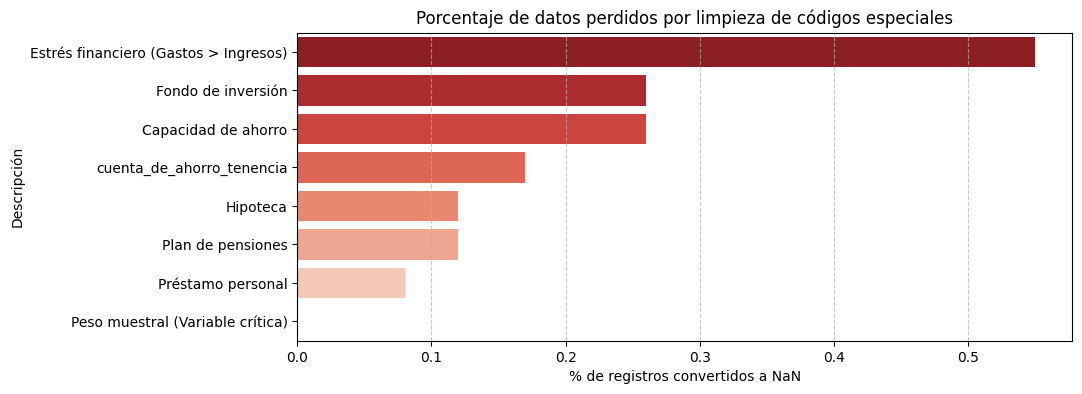

In [372]:
# Definimos las variables de interés para el análisis de pérdida (tenencia y comportamientos)
variables_analisis_perdida = {
    'b0308': 'cuenta_de_ahorro_tenencia',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión',
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal',
    'b1000j': 'Capacidad de ahorro',
    'j0200': 'Estrés financiero (Gastos > Ingresos)',
    'weight': 'Peso muestral (Variable crítica)'
}

perdida_datos = []

for var, nombre in variables_analisis_perdida.items():
    if var in eda.columns:
        nulos_antes = eda[var].isna().sum()
        # En eda_limpio ya están convertidos a NaN
        nulos_despues = eda_limpio[var].isna().sum()
        perdida_real = nulos_despues - nulos_antes
        porcentaje_perdida = (perdida_real / len(eda)) * 100

        perdida_datos.append({
            'Variable': var,
            'Descripción': nombre,
            'Registros perdidos (códigos esp.)': perdida_real,
            '% Pérdida': round(porcentaje_perdida, 2)
        })

df_perdida = pd.DataFrame(perdida_datos).sort_values('% Pérdida', ascending=False)
display(df_perdida)

# Visualización de la pérdida
plt.figure(figsize=(10, 4))
sns.barplot(data=df_perdida, x='% Pérdida', y='Descripción', palette='Reds_r')
plt.title('Porcentaje de datos perdidos por limpieza de códigos especiales')
plt.xlabel('% de registros convertidos a NaN')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Observación del Supervisor:** Una pérdida superior al 5-10% en variables clave como "Capacidad de ahorro" o "Ingresos" podría indicar un sesgo de respuesta. En este dataset, es vital monitorizar si los perfiles que "No contestan" siguen un patrón (ej. rentas altas o situaciones de vulnerabilidad extrema).

## 4. Variables base para segmentación

Se crean grupos de edad para poder comparar comportamientos financieros entre perfiles.

In [373]:
# Edad
# Asegurar que age no tenga NaNs antes de pd.cut para evitar errores en bins
if 'age' in eda_limpio.columns:
    eda_limpio['grupo_edad'] = pd.cut(
        eda_limpio['age'],
        bins=[18, 30, 40, 50, 60, 80],
        labels=['Jovenes', 'Adultos-jovenes', 'Adultos', 'Senior', 'Senior-mayores'],
        include_lowest=True
    )
else:
    print("Error: Columna 'age' no encontrada.")

# Peso muestral
peso = 'weight' if 'weight' in eda_limpio.columns else None

print('Grupos de edad:')
display(eda_limpio['grupo_edad'].value_counts(dropna=False).sort_index())

Grupos de edad:


C:\Users\raari\AppData\Local\Temp\ipykernel_27040\970828090.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eda_limpio['grupo_edad'] = pd.cut(


grupo_edad
Jovenes            1450
Adultos-jovenes    1219
Adultos            1784
Senior             1615
Senior-mayores     1696
Name: count, dtype: int64

## 5. Funciones simples para calcular porcentajes

Como estamos usando microdatos, los porcentajes se calculan a partir de respuestas individuales.

Para variables binarias:

- `1` = Sí / tiene / adquirió
- `0` = No

In [374]:
def porcentaje_si(df, variable, peso_col='weight'):
    """Calcula el porcentaje ponderado de respuestas 1 sobre respuestas 0/1.

    IMPORTANTE: Esta función define el 'Universo elegible' filtrando solo valores [0, 1].
    Los valores nulos (NaN) y códigos especiales convertidos previamente son excluidos del denominador.
    """
    temp = df[[variable, peso_col]].dropna() if peso_col in df.columns else df[[variable]].dropna()
    temp = temp[temp[variable].isin([0, 1])]

    if temp.empty:
        return np.nan

    if peso_col in temp.columns:
        return (temp[variable] * temp[peso_col]).sum() / temp[peso_col].sum() * 100
    else:
        return temp[variable].mean() * 100


def tabla_porcentajes(df, variables, peso_col='weight'):
    """Devuelve una tabla con porcentajes para un diccionario de variables."""
    filas = []
    for var, nombre in variables.items():
        if var in df.columns:
            filas.append({
                'variable': var,
                'indicador': nombre,
                'porcentaje': porcentaje_si(df, var, peso_col)
            })
    return pd.DataFrame(filas).sort_values('porcentaje', ascending=False)


def tabla_por_grupo(df, variables, grupo, peso_col='weight'):
    """Calcula porcentajes por grupo para varias variables binarias."""
    filas = []
    for var, nombre in variables.items():
        if var in df.columns:
            for categoria, subdf in df.groupby(grupo, observed=False):
                filas.append({
                    grupo: categoria,
                    'indicador': nombre,
                    'porcentaje': porcentaje_si(subdf, var, peso_col)
                })
    return pd.DataFrame(filas)


def grafico_barras(tabla, x='porcentaje', y='indicador', titulo='', color='#1E2F43'):
    tabla = tabla.dropna().sort_values(x)
    plt.figure(figsize=(10, 6), facecolor='#050a30')
    ax = plt.gca()
    ax.set_facecolor('#050a30')

    plt.barh(tabla[y], tabla[x], color=color)

    plt.xlabel('Porcentaje (%)', color='white', fontsize=14, labelpad=10)
    plt.title(titulo, fontsize=18, fontweight='bold', color='white', pad=20)

    ax.tick_params(colors='white', labelsize=12)

    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_alpha(0.3)

    plt.grid(axis='x', linestyle='--', alpha=0.2, color='white')
    plt.tight_layout()
    plt.show()


## 6. Mapa de variables de comportamiento financiero

Estas variables corresponden a productos financieros y comportamientos localizados en el CSV de microdatos. Si el equipo dispone del diccionario oficial, conviene revisar los nombres para confirmar la descripción exacta.

In [375]:


# 1. PRODUCTOS CORE (Foco Estratégico Bancario)
productos_core_tenencia = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo_personal',
    'Tarjeta_credito': 'Tarjeta_credito',
    'b0308': 'Cuenta_ahorro',
    'b0302': 'Plan_pensiones',
    'b0303': 'Fondo_inversión'
}

productos_core_adquisicion = {
    'b0401': 'Hipoteca',
    'b0406': 'Préstamo personal',
    'b0407': 'Tarjeta_credito',
    'b0408': 'Cuenta de ahorro',
    'b0402': 'Plan de pensiones',
    'b0403': 'Fondo de inversión'
}

# 2. PRODUCTOS NICHO O COMPLEMENTARIOS (Análisis Secundario)
productos_nicho_tenencia = {
    'b0304': 'Acciones',
    'b0305': 'Renta fija',
    'b0312': 'Criptomonedas',
    'b0310': 'Microcrédito'
}

productos_nicho_adquisicion = {
    'b0404': 'Acciones',
    'b0405': 'Renta fija',
    'b0412': 'Criptomonedas',
    'b0410': 'Microcrédito'
}

# 1. BLOQUE DE AHORRO Y RIQUEZA (Basado en Core)
productos_ahorro_inversion = {
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión'
}
comportamiento_ahorro_activo = {
    'b1000j': 'Hogar ahorrador (últimos 12 meses)'
}

# 2. BLOQUE DE DEUDA Y SALUD FINANCIERA (Basado en Core)
productos_deuda = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal',
    'Tarjeta_credito': 'Tarjeta_credito'
}
estres_financiero = {
    'j0200': 'Gastos > Ingresos (Estrés Financiero)'
}

# 3. BLOQUE DE ACCESO AL SISTEMA CREDITICIO (Exclusión)
barreras_credito = {
    'j0900a': 'Préstamo rechazado',
    'j0900b': 'Cuantía concedida inferior',
    'j0900c': 'No solicitado por miedo al rechazo'
}

# Comportamientos generales (para compatibilidad con secciones posteriores)
comportamientos_generales = {
    'b1000j': 'Capacidad de ahorro',
    'j0200': 'Estrés financiero'
}

# Tenencia de productos financieros (General - Simplificado a Core para Estrategia)
productos_tenencia = productos_core_tenencia

# Adquisición reciente de productos financieros (General - Simplificado a Core para Estrategia)
productos_adquisicion = productos_core_adquisicion

## 7. Tenencia y estados de la cartera de productos

Aquí se analiza qué productos financieros tiene la población en 2021 y cuál es su dinámica de mantenimiento o adquisición reciente.

### 7.1. Línea 1: Ahorro e Inversión (Vehículos y Capacidad Activa)

Análisis de la tenencia de vehículos de ahorro y la capacidad de ahorro activa del hogar en los últimos 12 meses.


In [376]:
# 7.1.1 Vehículos de ahorro e inversión
tenencia_ahorro = tabla_porcentajes(eda_limpio, productos_ahorro_inversion)
display(tenencia_ahorro)

# 7.1.2 Capacidad de ahorro activa
ahorro_activo = tabla_porcentajes(eda_limpio, comportamiento_ahorro_activo)
display(ahorro_activo)


,variable,indicador,porcentaje
1,b0302,Plan de pensiones,20.686348
0,b0308,Cuenta de ahorro,17.541546
2,b0303,Fondo de inversión,11.618110


,variable,indicador,porcentaje
0,b1000j,Hogar ahorrador (últimos 12 meses),29.933046


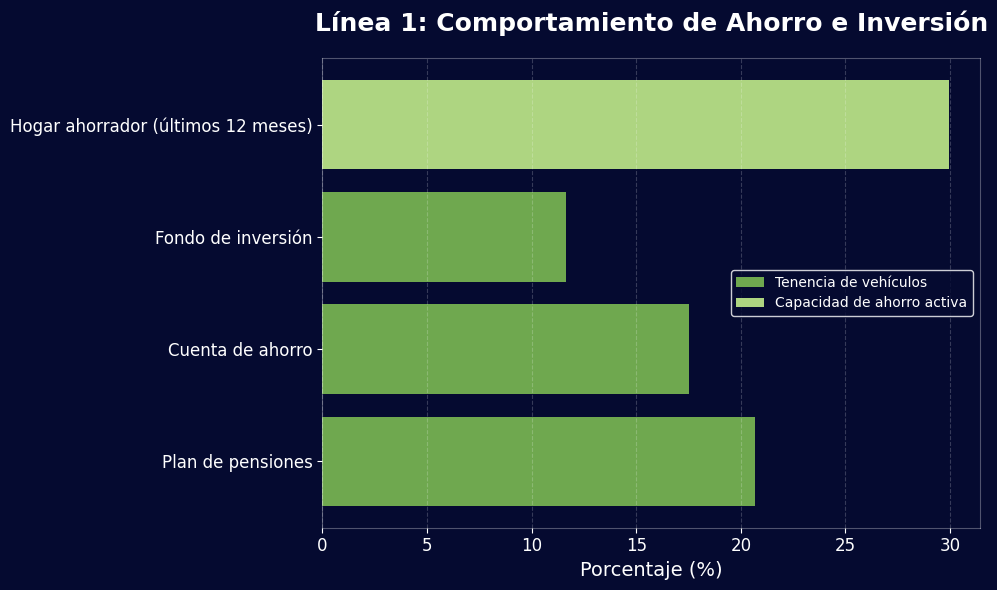

In [377]:
# Visualización Línea 1
plt.figure(figsize=(10, 6), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

plt.barh(tenencia_ahorro['indicador'], tenencia_ahorro['porcentaje'], color='#6FA84F', label='Tenencia de vehículos')
plt.barh(ahorro_activo['indicador'], ahorro_activo['porcentaje'], color='#AED581', label='Capacidad de ahorro activa')

plt.xlabel('Porcentaje (%)', color='white', fontsize=14)
plt.title('Línea 1: Comportamiento de Ahorro e Inversión', fontsize=18, fontweight='bold', color='white', pad=20)
ax.tick_params(colors='white', labelsize=12)

plt.legend(facecolor='#050a30', edgecolor='white', labelcolor='white')
for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_alpha(0.3)

plt.grid(axis='x', linestyle='--', alpha=0.2, color='white')
plt.tight_layout()
plt.show()


### 7.2. Línea 2: Deuda y Resiliencia (Riesgo y Exclusión)

Este bloque analiza el endeudamiento, el estrés financiero y las barreras de acceso al crédito.


In [378]:
# 7.2.1 Productos de deuda
tenencia_deuda = tabla_porcentajes(eda_limpio, productos_deuda)
display(tenencia_deuda)

# 7.2.2 Estrés Financiero (Gastos > Ingresos)
estres = tabla_porcentajes(eda_limpio, estres_financiero)
display(estres)

# 7.2.3 Acceso al Sistema Crediticio (Exclusión)
exclusion = tabla_porcentajes(eda_limpio, barreras_credito)
display(exclusion)


,variable,indicador,porcentaje
2,Tarjeta_credito,Tarjeta_credito,64.313560
0,b0301,Hipoteca,29.353860
1,b0306,Préstamo personal,21.175191


,variable,indicador,porcentaje
0,j0200,Gastos > Ingresos (Estrés Financiero),25.432683


,variable,indicador,porcentaje
0,j0900a,Préstamo rechazado,3.657656
2,j0900c,No solicitado por miedo al rechazo,2.906136
1,j0900b,Cuantía concedida inferior,1.824149


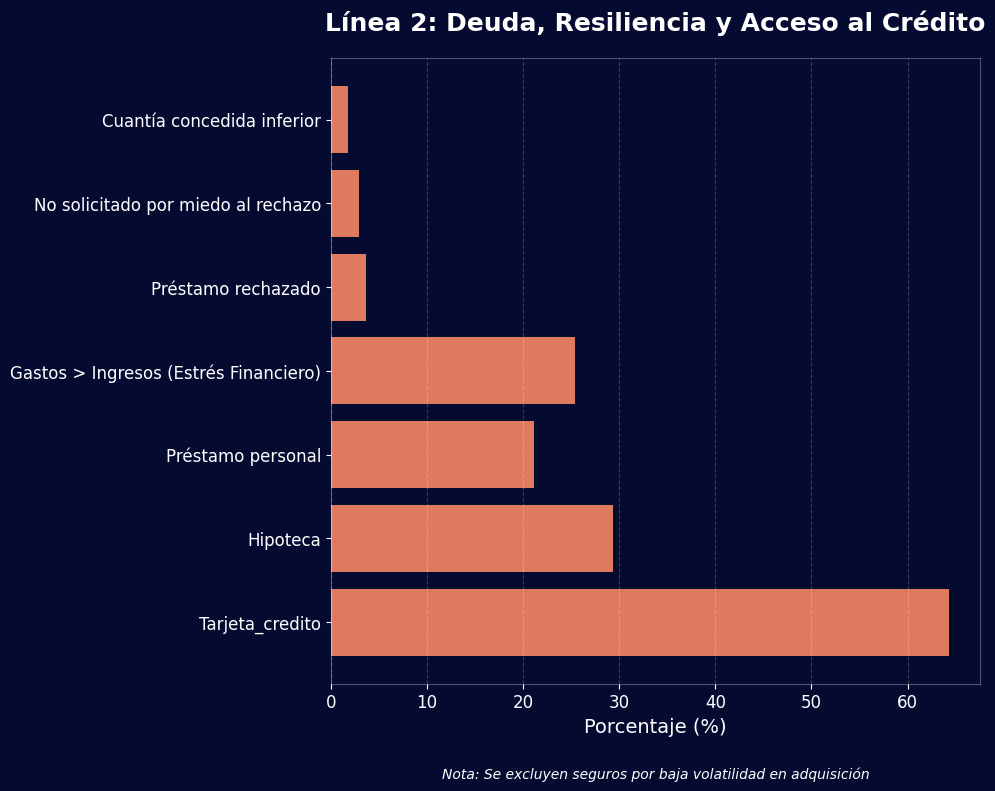

In [379]:
# Visualización Línea 2
plt.figure(figsize=(10, 8), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

# Combinamos indicadores para una sola gráfica de salud financiera
salud_fin = pd.concat([tenencia_deuda, estres, exclusion])

plt.barh(salud_fin['indicador'], salud_fin['porcentaje'], color='#E07A5F')
plt.xlabel('Porcentaje (%)', color='white', fontsize=14)
plt.title('Línea 2: Deuda, Resiliencia y Acceso al Crédito', fontsize=18, fontweight='bold', color='white', pad=20)
ax.tick_params(colors='white', labelsize=12)

plt.annotate('Nota: Se excluyen seguros por baja volatilidad en adquisición',
             xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=10, fontstyle='italic', color='white')

for spine in ax.spines.values():
    spine.set_color('white')
    spine.set_alpha(0.3)

plt.grid(axis='x', linestyle='--', alpha=0.2, color='white')
plt.tight_layout()
plt.show()


### 7.3. Visión General y Dinámica de la Cartera (Tenencia vs. Adquisición)

A continuación se analiza la penetración general y se desglosa, para cada producto, la distribución ponderada de cuatro estados mutuamente excluyentes:

1) **Nuevo (Adquirió y tiene):** Proxy de "no lo tenía y ahora sí".
2) **Mantiene (Tiene sin adquisición reciente):** Proxy de "lo tenía y lo mantiene".
3) **Abandono (Adquirió pero no lo tiene):** Posible cancelación.
4) **No mercado (Ni tenía ni tiene).**

Nota metodológica: La ECF no proporciona una variable directa de "tenencia hace 2 años". Estas categorías son aproximaciones operativas basadas en `b03xx` (tenencia actual) y `b04xx` (adquisición en los últimos 2 años).


<Figure size 1000x800 with 0 Axes>

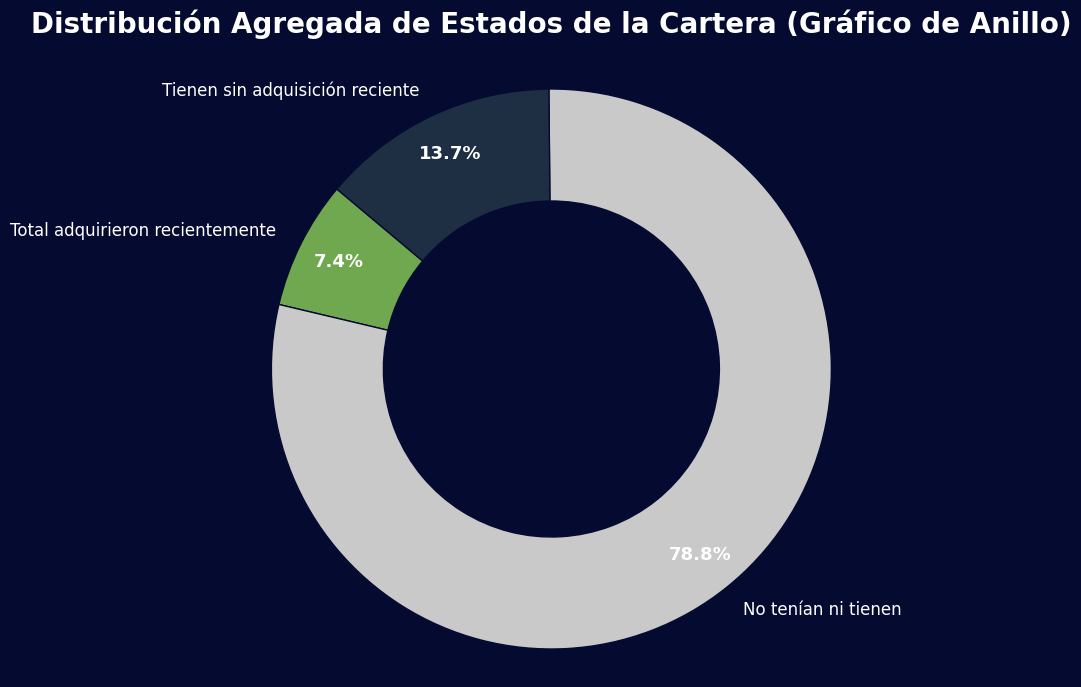

,variable,indicador,adquirio_y_lo_tiene_%,tiene_sin_adquisicion_reciente_%,adquirio_y_no_lo_tiene_%,no_tenia_ni_tiene_%
0,b0301,Hipoteca,4.32,24.99,0.24,70.45
1,b0306,Préstamo_personal,13.18,7.96,3.02,75.84
3,b0302,Plan_pensiones,2.32,18.33,0.20,79.15
2,b0308,Cuenta_ahorro,5.35,12.02,1.43,81.19
4,b0303,Fondo_inversión,6.14,5.44,0.85,87.58


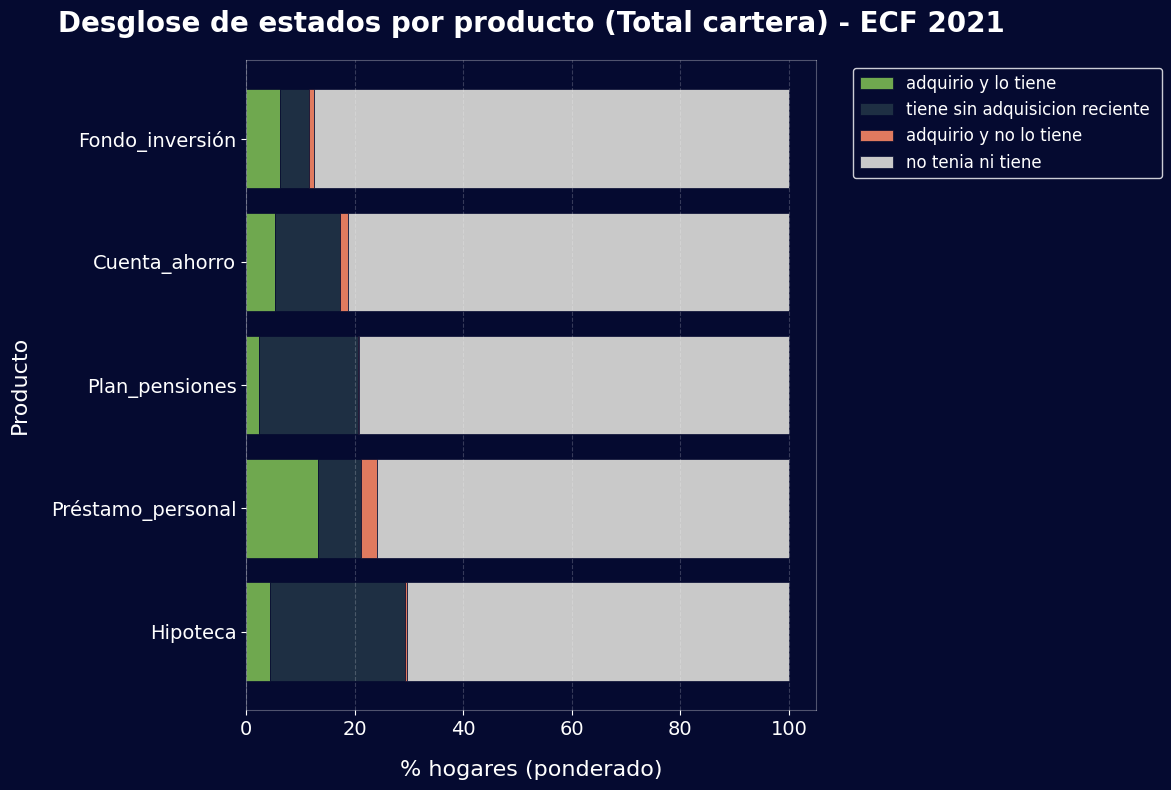

In [380]:
import numpy as np
import pandas as pd

def desglose_tenencia_adquisicion(df, mapa_tenencia, peso_col='weight'):
    """Devuelve una tabla con el % ponderado de 4 estados por producto, usando b03xx (tenencia) y b04xx (adquisición).
    Requiere que para cada clave de b03xx exista su par b04xx correspondiente (mismo sufijo).
    """
    filas = []

    for b03, nombre in mapa_tenencia.items():
        if not str(b03).startswith('b03'):
            continue
        sufijo = str(b03).replace('b03', '')
        b04 = f"b04{sufijo}"
        if b03 not in df.columns or b04 not in df.columns:
            continue

        sub = df[[b03, b04] + ([peso_col] if peso_col in df.columns else [])].copy()
        # Normalizamos a 0/1 y removemos NaN en el par
        for c in [b03, b04]:
            sub[c] = pd.to_numeric(sub[c], errors='coerce')
            sub[c] = sub[c].where(sub[c].isin([0, 1]), np.nan)
        sub = sub.dropna(subset=[b03, b04])
        pesos = sub[peso_col] if peso_col in sub.columns else None

        tiene = sub[b03] == 1
        adquiere = sub[b04] == 1

        # 4 estados mutuamente excluyentes
        estado_1 = adquiere & tiene                              # Adquirió reciente y lo tiene (proxy de nuevo)
        estado_2 = (~adquiere) & tiene                           # Tiene sin adquisición reciente (mantiene)
        estado_3 = adquiere & (~tiene)                           # Adquirió pero no lo tiene ahora (posible abandono)
        estado_4 = (~adquiere) & (~tiene)                        # No tenía ni tiene

        denom = pesos.sum() if pesos is not None else len(sub)
        if denom == 0:
            nuevo = mantiene = abandono = nunca = np.nan
        else:
            if pesos is not None:
                nuevo = (pesos[estado_1].sum() / denom) * 100
                mantiene = (pesos[estado_2].sum() / denom) * 100
                abandono = (pesos[estado_3].sum() / denom) * 100
                nunca = (pesos[estado_4].sum() / denom) * 100
            else:
                nuevo = estado_1.mean() * 100
                mantiene = estado_2.mean() * 100
                abandono = estado_3.mean() * 100
                nunca = estado_4.mean() * 100

        filas.append({
            'variable': b03,
            'indicador': nombre,
            'adquirio_y_lo_tiene_%': round(nuevo, 2),
            'tiene_sin_adquisicion_reciente_%': round(mantiene, 2),
            'adquirio_y_no_lo_tiene_%': round(abandono, 2),
            'no_tenia_ni_tiene_%': round(nunca, 2)
        })

    return pd.DataFrame(filas).sort_values('no_tenia_ni_tiene_%', ascending=True)

# Construimos el mapa de tenencia restringido a productos que también tengan su par de adquisición
mapa_tenencia_con_par = {k: v for k, v in productos_tenencia.items() if k.replace('b03', 'b04') in eda_limpio.columns}

desglose_7_3 = desglose_tenencia_adquisicion(eda_limpio, mapa_tenencia_con_par, peso_col='weight')

# Gráfico de Anillo (Donut Chart) - Distribución Agregada de Estados de la Cartera
plt.figure(figsize=(10, 8))
try:
    # Calculamos la media ponderada de los estados sobre todos los productos de la cartera
    media_adquirio = (desglose_7_3['adquirio_y_lo_tiene_%'] + desglose_7_3['adquirio_y_no_lo_tiene_%']).mean()
    media_mantiene = desglose_7_3['tiene_sin_adquisicion_reciente_%'].mean()
    media_no_tenia = desglose_7_3['no_tenia_ni_tiene_%'].mean()

    valores_tarta = [media_adquirio, media_no_tenia, media_mantiene]
    etiquetas_tarta = [
        'Total adquirieron recientemente',
        'No tenían ni tienen',
        'Tienen sin adquisición reciente'
    ]
    colores_tarta = ['#6FA84F', '#C9C9C9', '#1E2F43']

    # Gráfico de Anillo (Donut Chart) - Distribución Agregada de Estados
    plt.figure(figsize=(10, 8), facecolor='#050a30')
    ax = plt.gca()
    ax.set_facecolor('#050a30')

    # Textos del anillo en blanco
    patches, texts, autotexts = plt.pie(
        valores_tarta,
        labels=etiquetas_tarta,
        autopct='%1.1f%%',
        colors=colores_tarta,
        startangle=140,
        pctdistance=0.85, # Distancia de los porcentajes al centro
        textprops={'color': 'white', 'fontsize': 12},
        wedgeprops={'width': 0.4, 'edgecolor': '#050a30'} # Grosor del anillo y color del borde
    )

    # Ajustar color de porcentajes dentro de la tarta
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(13)

    plt.title('Distribución Agregada de Estados de la Cartera (Gráfico de Anillo)',
              fontsize=20, fontweight='bold', color='white', pad=20)
    plt.axis('equal')  # Para que el gráfico sea un círculo
    plt.show()
except Exception as e:
    print('Aviso visualización Tarta 7.5:', e)

display(desglose_7_3)

# Visualización de estados para todos los productos (Barras Apiladas)
try:
    plt.figure(figsize=(12, 8), facecolor='#050a30')
    ax = plt.gca()
    ax.set_facecolor('#050a30')

    top = desglose_7_3.copy()
    indicadores = top['indicador']
    y_pos = np.arange(len(indicadores))
    estados = ['adquirio_y_lo_tiene_%', 'tiene_sin_adquisicion_reciente_%', 'adquirio_y_no_lo_tiene_%', 'no_tenia_ni_tiene_%']
    colores = ['#6FA84F', '#1E2F43', '#E07A5F', '#C9C9C9']

    left = np.zeros(len(indicadores))
    for est, col in zip(estados, colores):
        plt.barh(indicadores, top[est], left=left, color=col,
                 label=est.replace('_', ' ').replace('%',''),
                 edgecolor='#050a30', linewidth=0.5)
        left += top[est]

    plt.xlabel('% hogares (ponderado)', color='white', fontsize=16, labelpad=15)
    plt.ylabel('Producto', color='white', fontsize=16, labelpad=15)
    plt.title('Desglose de estados por producto (Total cartera) - ECF 2021',
              fontsize=20, fontweight='bold', color='white', pad=20)

    # Ajuste de ticks
    ax.tick_params(colors='white', labelsize=14)

    # Leyenda amigable
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               facecolor='#050a30', edgecolor='white', labelcolor='white', fontsize=12)

    plt.grid(axis='x', linestyle='--', alpha=0.2, color='white')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_alpha(0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Aviso visualización 7.3:', e)


**Nota sobre el Universo de Análisis:** Los porcentajes se calculan sobre el **Universo elegible** (registros con respuesta válida 0 o 1). Se garantiza que los códigos de salto (como el -98) no distorsionen las tasas de penetración reales.

**Lectura de negocio:** Los productos con alto "Mantenimiento" son la base del negocio. Aquellos con alto "Nuevo" indican dinamismo comercial actual.


## 8. Adquisición reciente de productos financieros

Análisis de la demanda activa en los últimos 2 años para los productos core del banco.


In [381]:
adquisicion = tabla_porcentajes(eda_limpio, productos_adquisicion)
display(adquisicion)


,variable,indicador,porcentaje
2,b0407,Tarjeta_credito,16.924254
1,b0406,Préstamo personal,16.204244
5,b0403,Fondo de inversión,6.979977
3,b0408,Cuenta de ahorro,6.776995
0,b0401,Hipoteca,4.564695
4,b0402,Plan de pensiones,2.520230


**Nota sobre el Universo de Análisis (Adquisición):** El análisis se centra exclusivamente en los sujetos elegibles según el diseño de la encuesta, garantizando que los códigos de salto no distorsionen las tasas de penetración reales.


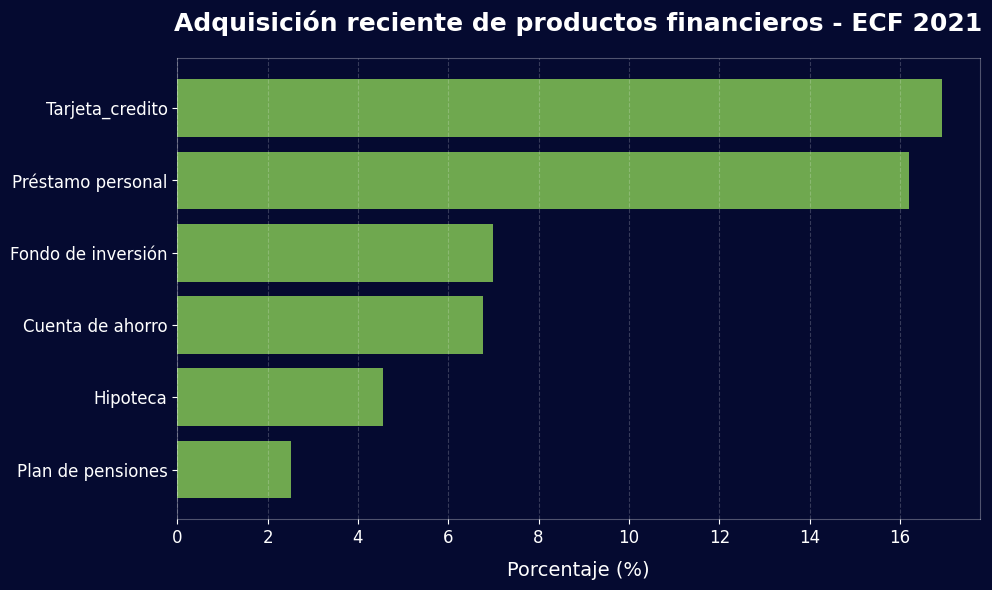

In [382]:
grafico_barras(
    adquisicion,
    titulo='Adquisición reciente de productos financieros - ECF 2021',
    color='#6FA84F'  # verde corporativo
)


**Lectura de negocio:** Los productos con mayor adquisición reciente indican los puntos calientes de demanda. Representan las mejores oportunidades para campañas de captación a corto plazo.


## 9. Análisis de Oportunidad de Negocio (Tenencia vs. Adquisición)

Este apartado cruza la foto estática (lo que el cliente tiene) con la dinámica (lo que el cliente contrata) para priorizar acciones comerciales.

In [383]:
# Matriz de Oportunidad de Negocio
tenencia_simple = desglose_7_3[['indicador', 'tiene_sin_adquisicion_reciente_%', 'adquirio_y_lo_tiene_%']].copy()
tenencia_simple['tenencia_total_%'] = tenencia_simple['tiene_sin_adquisicion_reciente_%'] + tenencia_simple['adquirio_y_lo_tiene_%']
adquisicion_simple = adquisicion[['indicador', 'porcentaje']].rename(columns={'porcentaje': 'adquisicion_reciente_%'})

comparativa = tenencia_simple.merge(adquisicion_simple, on='indicador', how='left')

# Clasificación para interpretar oportunidades de negocio
umbral_tenencia = 10.0      # Umbral de penetración de mercado
umbral_adquisicion = 2.0    # Umbral de flujo de contratación

def clasificar_oportunidad(row):
    if row['tenencia_total_%'] >= umbral_tenencia and row['adquisicion_reciente_%'] >= umbral_adquisicion:
        return 'Producto fuerte: mantener e impulsar venta cruzada'
    elif row['tenencia_total_%'] >= umbral_tenencia and row['adquisicion_reciente_%'] < umbral_adquisicion:
        return 'Producto maduro: fidelización y productos complementarios'
    elif row['tenencia_total_%'] < umbral_tenencia and row['adquisicion_reciente_%'] >= umbral_adquisicion:
        return 'Producto emergente: reforzar captación'
    else:
        return 'Baja adopción: simplificar oferta y mejorar comunicación'

comparativa['lectura_negocio'] = comparativa.apply(clasificar_oportunidad, axis=1)
display(comparativa.sort_values('tenencia_total_%', ascending=False))


,indicador,tiene_sin_adquisicion_reciente_%,adquirio_y_lo_tiene_%,tenencia_total_%,adquisicion_reciente_%,lectura_negocio
0,Hipoteca,24.99,4.32,29.31,4.564695,Producto fuerte: mantener e impulsar venta cru...
1,Préstamo_personal,7.96,13.18,21.14,NaN,Baja adopción: simplificar oferta y mejorar co...
2,Plan_pensiones,18.33,2.32,20.65,NaN,Baja adopción: simplificar oferta y mejorar co...
3,Cuenta_ahorro,12.02,5.35,17.37,NaN,Baja adopción: simplificar oferta y mejorar co...
4,Fondo_inversión,5.44,6.14,11.58,NaN,Baja adopción: simplificar oferta y mejorar co...


### 9.1. Desglose de estados para Productos Clave (Zoom)

Visualizamos la salud de la cartera para los productos estratégicos del banco.


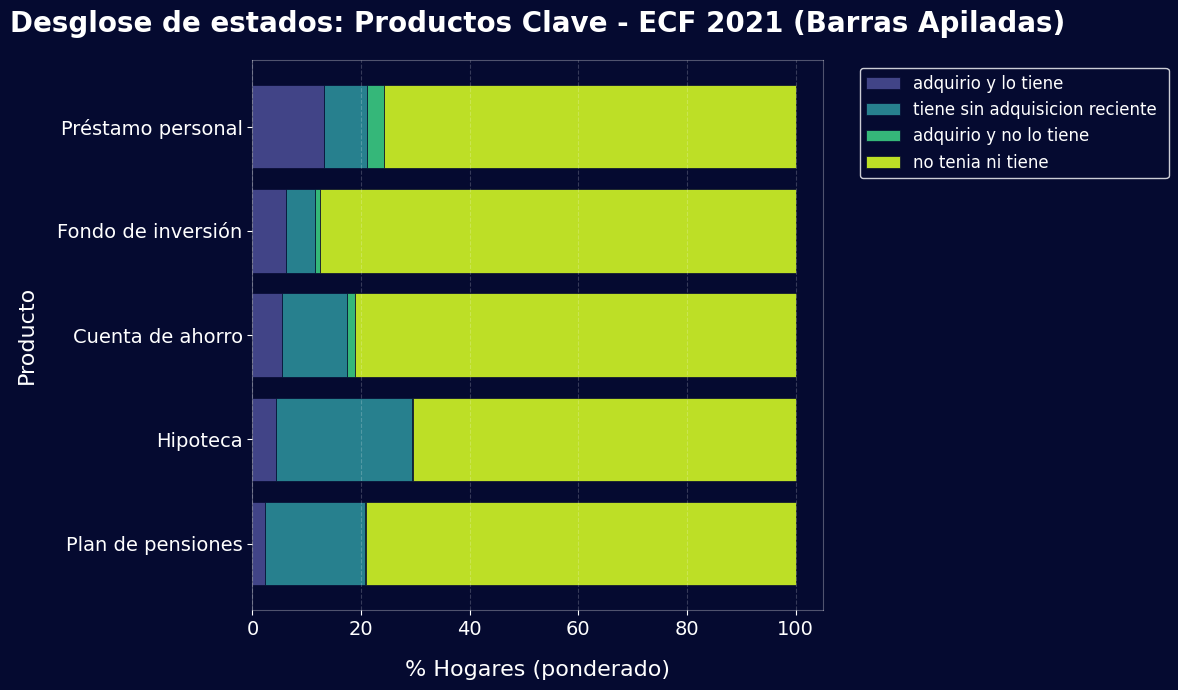

In [384]:
# Generamos el desglose solo para productos clave
productos_clave = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal',
    'b0307': 'Tarjeta_credito',
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión'
}
mapa_clave_con_par = {k: v for k, v in productos_clave.items() if k.replace('b03', 'b04') in eda_limpio.columns}
desglose_clave = desglose_tenencia_adquisicion(eda_limpio, mapa_clave_con_par, peso_col='weight')

# Visualización de estados para productos clave (Barras Apiladas)
try:
    plt.figure(figsize=(12, 7), facecolor='#050a30')
    ax = plt.gca()
    ax.set_facecolor('#050a30')

    top = desglose_clave.copy().sort_values('adquirio_y_lo_tiene_%', ascending=True)
    indicadores = top['indicador']
    left = np.zeros(len(indicadores))

    # Definimos los estados y sus colores (usamos la paleta viridis para un degradado profesional)
    estados = ['adquirio_y_lo_tiene_%', 'tiene_sin_adquisicion_reciente_%', 'adquirio_y_no_lo_tiene_%', 'no_tenia_ni_tiene_%']


    # Generamos 4 colores de la paleta viridis
    colores = [plt.cm.viridis(i) for i in np.linspace(0.2, 0.9, len(estados))]

    for est, col in zip(estados, colores):
        plt.barh(indicadores, top[est], left=left, color=col,
                 label=est.replace('_', ' ').replace('%',''),
                 edgecolor='#050a30', linewidth=0.5)
        left += top[est]

    plt.xlabel('% Hogares (ponderado)', color='white', fontsize=16, labelpad=15)
    plt.ylabel('Producto', color='white', fontsize=16, labelpad=15)
    plt.title('Desglose de estados: Productos Clave - ECF 2021 (Barras Apiladas)',
              fontsize=20, fontweight='bold', color='white', pad=20)

    # Ajuste de ticks
    ax.tick_params(colors='white', labelsize=14)

    # Leyenda amigable
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               facecolor='#050a30', edgecolor='white', labelcolor='white', fontsize=12)

    plt.grid(axis='x', linestyle='--', alpha=0.2, color='white')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_alpha(0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Aviso visualización productos clave:', e)


**Lectura de negocio:**

- Alta tenencia y alta adquisición: productos activos y relevantes.
- Alta tenencia y baja adquisición: productos maduros, útiles para fidelización o venta cruzada.
- Baja tenencia y cierta adquisición: productos con posible oportunidad de crecimiento.

# 10. Perfil demográfico y comportamiento financiero global

Este apartado analiza cómo varían la tenencia y adquisición de productos financieros según el grupo de edad de la población.


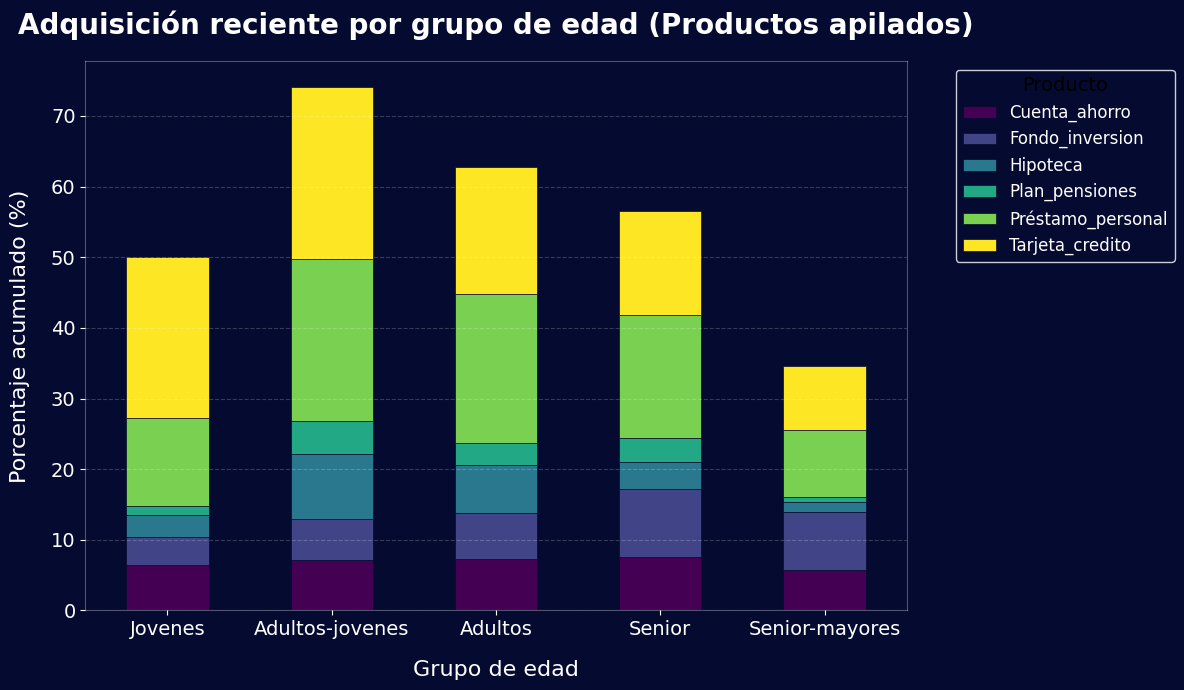

In [385]:
# Definición de productos para visualización de adquisición (Selección de los 6 productos clave de negocio)
productos_heatmap_adquisicion = {
    'b0401': 'Hipoteca',
    'b0406': 'Préstamo_personal',
    'b0407': 'Tarjeta_credito',
    'b0408': 'Cuenta_ahorro',
    'b0402': 'Plan_pensiones',
    'b0403': 'Fondo_inversion'
}

# Nos aseguramos de usar solo columnas que existan en el dataset
productos_heatmap_adquisicion = {
    col: nombre
    for col, nombre in productos_heatmap_adquisicion.items()
    if col in eda_limpio.columns
}

# Gráficos de adquisición reciente por edad y producto (Barras Apiladas)

# 1. Eje X: Rangos de edad | Eje Y: Porcentaje de adquisición por producto
adq_por_edad = tabla_por_grupo(eda_limpio, productos_heatmap_adquisicion, 'grupo_edad')
adq_pivot = adq_por_edad.pivot(index='grupo_edad', columns='indicador', values='porcentaje')

# Aseguramos el orden de edad
orden_edad = ['Jovenes', 'Adultos-jovenes', 'Adultos', 'Senior', 'Senior-mayores']
adq_pivot = adq_pivot.reindex(orden_edad)

plt.figure(figsize=(12, 7), facecolor='#050a30')
ax1 = plt.gca()
ax1.set_facecolor('#050a30')

adq_pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis', edgecolor='#050a30', linewidth=0.5)

plt.title('Adquisición reciente por grupo de edad (Productos apilados)',
          fontsize=20, fontweight='bold', color='white', pad=20)
plt.xlabel('Grupo de edad', color='white', fontsize=16, labelpad=15)
plt.ylabel('Porcentaje acumulado (%)', color='white', fontsize=16, labelpad=15)

# Ajuste de ticks
ax1.tick_params(colors='white', labelsize=14)
plt.xticks(rotation=0) # Mantener etiquetas horizontales para legibilidad

# Leyenda amigable
plt.legend(title='Producto', title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left',
           facecolor='#050a30', edgecolor='white', labelcolor='white', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.2, color='white')

# Eliminar bordes innecesarios
for spine in ax1.spines.values():
    spine.set_color('white')
    spine.set_alpha(0.3)

plt.tight_layout()
plt.show()




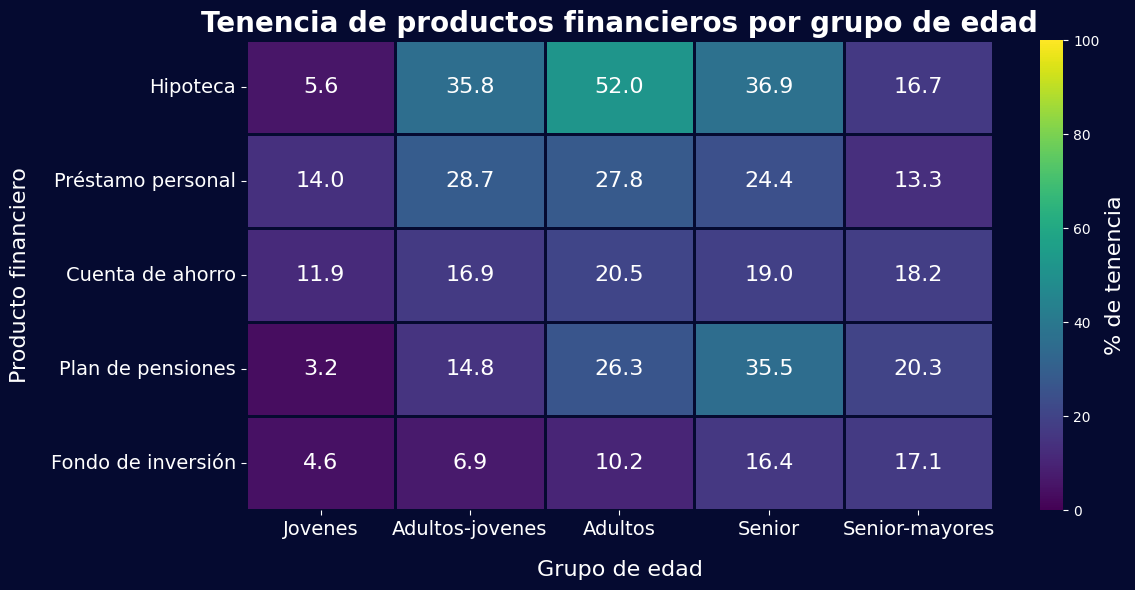

In [386]:
# 10.1 Heatmap de tenencia de productos por grupo de edad

# Productos financieros: columnas de tenencia (Selección de los 6 productos clave de negocio)
productos_heatmap_tenencia = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo personal',
    'b307': 'Tarjeta_credito',
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión'
}

# Nos aseguramos de usar solo columnas que existan en el dataset
productos_heatmap_tenencia = {
    col: nombre
    for col, nombre in productos_heatmap_tenencia.items()
    if col in eda_limpio.columns
}

# Calculamos porcentajes por grupo de edad
edad_tenencia_heatmap = tabla_por_grupo(
    eda_limpio,
    productos_heatmap_tenencia,
    'grupo_edad'
)

# Convertimos a formato matriz para heatmap
heatmap_tenencia = edad_tenencia_heatmap.pivot(
    index='indicador',
    columns='grupo_edad',
    values='porcentaje'
)

# Orden recomendado de productos
orden_productos = [
    'Hipoteca',
    'Préstamo personal',
    'Tarjeta_credito',
    'Cuenta de ahorro',
    'Plan de pensiones',
    'Fondo de inversión'
]

# Ordenamos solo los productos que existan
heatmap_tenencia = heatmap_tenencia.loc[
    [p for p in orden_productos if p in heatmap_tenencia.index]
]

# Orden recomendado de grupos de edad
orden_edad = ['Jovenes', 'Adultos-jovenes', 'Adultos', 'Senior', 'Senior-mayores']

heatmap_tenencia = heatmap_tenencia[
    [g for g in orden_edad if g in heatmap_tenencia.columns]
]

# Gráfico
plt.figure(figsize=(12, 6), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

sns.heatmap(
    heatmap_tenencia,
    annot=True,
    fmt='.1f',
    cmap='viridis',
    vmin=0,
    vmax=100,
    linewidths=0.8,
    linecolor='#050a30',
    cbar_kws={'label': '% de tenencia'},
    annot_kws={'color': 'white', 'size': 16}
)

plt.title(
    'Tenencia de productos financieros por grupo de edad',
    fontsize=20,
    fontweight='bold',
    color='white'
)

plt.xlabel('Grupo de edad', color='white', fontsize=16, labelpad=15)
plt.ylabel('Producto financiero', color='white', fontsize=16, labelpad=15)
ax.tick_params(colors='white', labelsize=14)

# Ajustamos el color de la barra de color (colorbar)
cbar = ax.collections[0].colorbar
cbar.set_label('% de tenencia', color='white', size=16)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

Conclusión: la tenencia de productos muestra que algunos productos están consolidados en todas las edades, como cuentas y tarjetas, mientras que otros dependen más de la etapa de vida, como hipotecas, préstamos o planes de pensiones.

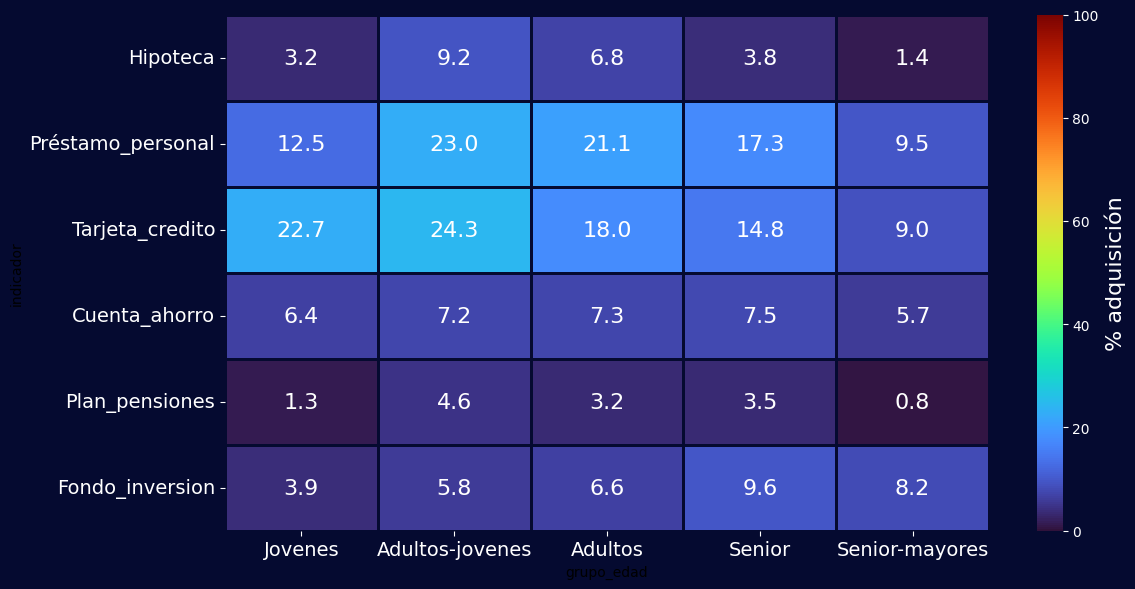

In [396]:
# 10.2 Heatmap de adquisición reciente por grupo de edad

# Calculamos porcentajes por grupo de edad
edad_adquisicion_heatmap = tabla_por_grupo(
    eda_limpio,
    productos_heatmap_adquisicion,
    'grupo_edad'
)

# Convertimos a formato matriz para heatmap
heatmap_adquisicion = edad_adquisicion_heatmap.pivot(
    index='indicador',
    columns='grupo_edad',
    values='porcentaje'
)

# Mismo orden recomendado de productos Core
orden_productos = [
    'Hipoteca',
    'Préstamo_personal',
    'Tarjeta_credito',
    'Cuenta_ahorro',
    'Plan_pensiones',
    'Fondo_inversion'
]

# Ordenamos solo los productos que existan
heatmap_adquisicion = heatmap_adquisicion.loc[
    [p for p in orden_productos if p in heatmap_adquisicion.index]
]

# Orden recomendado de grupos de edad
orden_edad = ['Jovenes', 'Adultos-jovenes', 'Adultos', 'Senior', 'Senior-mayores']

heatmap_adquisicion = heatmap_adquisicion[
    [g for g in orden_edad if g in heatmap_adquisicion.columns]
]

# Gráfico
plt.figure(figsize=(12, 6), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')


sns.heatmap(
    heatmap_adquisicion,
    annot=True,
    fmt='.1f',
    cmap='turbo',
    vmin=0,
    vmax=100,
    linewidths=0.8,
    linecolor='#050a30',
    cbar_kws={'label': '% de adquisición reciente'},
    annot_kws={'size': 16}
)



'''plt.title(
    'Adquisición reciente de productos financieros por grupo de edad',
    fontsize=20,
    fontweight='bold',
    color='white',
    pad=20
)'''

#plt.xlabel('Grupo de edad', color='white', fontsize=16, labelpad=15)
#plt.ylabel('Producto financiero', color='white', fontsize=16, labelpad=15)
ax.tick_params(colors='white', labelsize=14)

# Ajustamos el color de la barra de color (colorbar)
cbar = ax.collections[0].colorbar
cbar.set_label('% adquisición', color='white', size=16)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

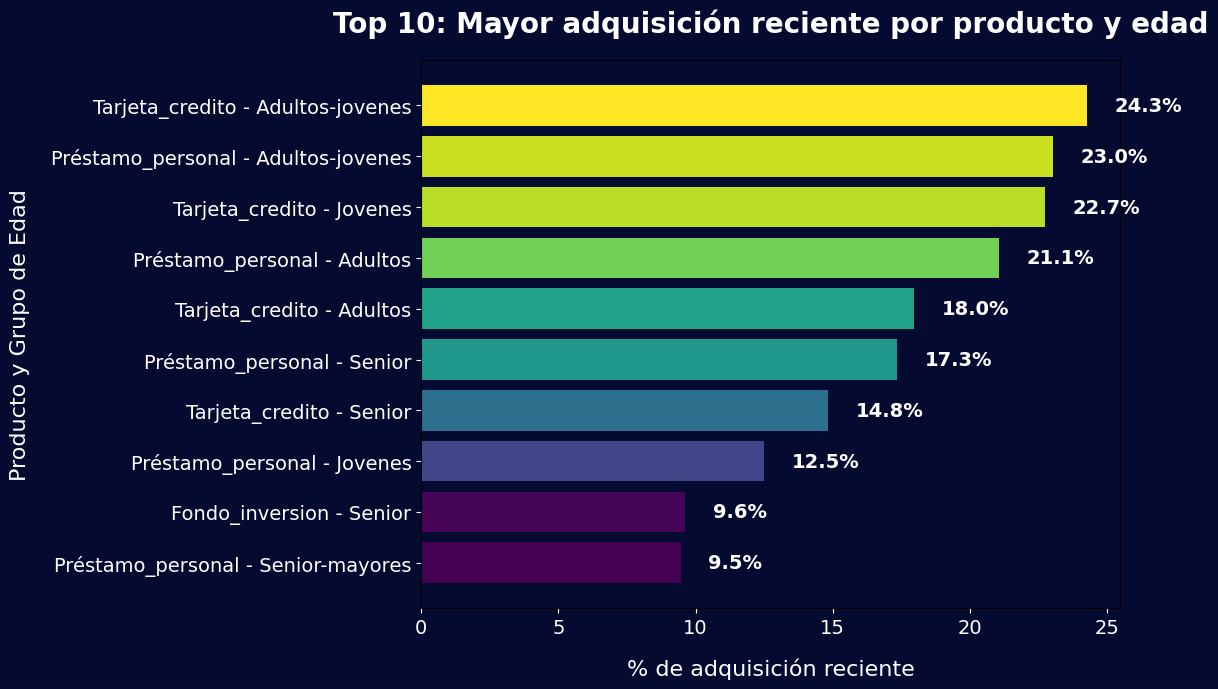

In [388]:
# 10.3 Top 10 combinaciones de adquisición reciente
top_10_adquisicion = edad_adquisicion_heatmap.sort_values(by='porcentaje', ascending=False).head(10).copy()
top_10_adquisicion['combinacion'] = top_10_adquisicion['indicador'] + " - " + top_10_adquisicion['grupo_edad'].astype(str)

plt.figure(figsize=(12, 7), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

# Usamos viridis para el color de las barras para mantener consistencia
norm = plt.Normalize(top_10_adquisicion['porcentaje'].min(), top_10_adquisicion['porcentaje'].max())
colors = plt.cm.viridis(norm(top_10_adquisicion['porcentaje']))

bars = plt.barh(top_10_adquisicion['combinacion'], top_10_adquisicion['porcentaje'], color=colors)
plt.gca().invert_yaxis()  # El valor más alto arriba

plt.title('Top 10: Mayor adquisición reciente por producto y edad', fontsize=20, fontweight='bold', color='white', pad=20)
plt.xlabel('% de adquisición reciente', color='white', fontsize=16, labelpad=15)
plt.ylabel('Producto y Grupo de Edad', color='white', fontsize=16, labelpad=15)
ax.tick_params(colors='white', labelsize=14)

# Añadimos etiquetas de valor en las barras
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Conclusión: la contratación reciente varía claramente por edad: los jóvenes destacan en tarjetas, las edades medias en préstamos, seguros e hipotecas, y los perfiles de mayor edad muestran más oportunidad en ahorro e inversión conservadora

## 11. Comportamiento financiero por edad de cada producto

Se analizan productos clave por grupo de edad.

,grupo_edad,indicador,porcentaje
0,Jovenes,Hipoteca,5.563839
1,Adultos-jovenes,Hipoteca,35.790591
2,Adultos,Hipoteca,52.020614
3,Senior,Hipoteca,36.872719
4,Senior-mayores,Hipoteca,16.702360
5,Jovenes,Préstamo_personal,13.962128
6,Adultos-jovenes,Préstamo_personal,28.693639
7,Adultos,Préstamo_personal,27.808829
8,Senior,Préstamo_personal,24.386319
9,Senior-mayores,Préstamo_personal,13.324765


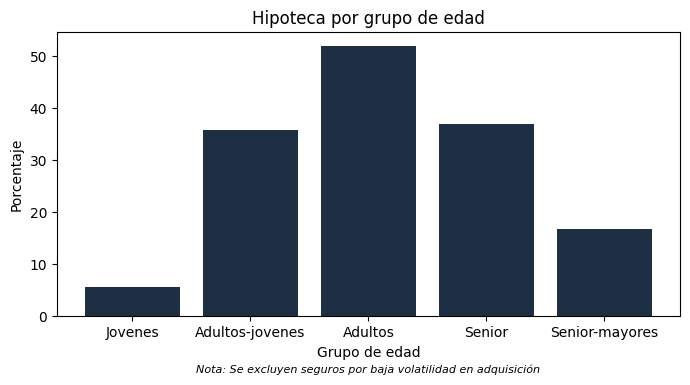

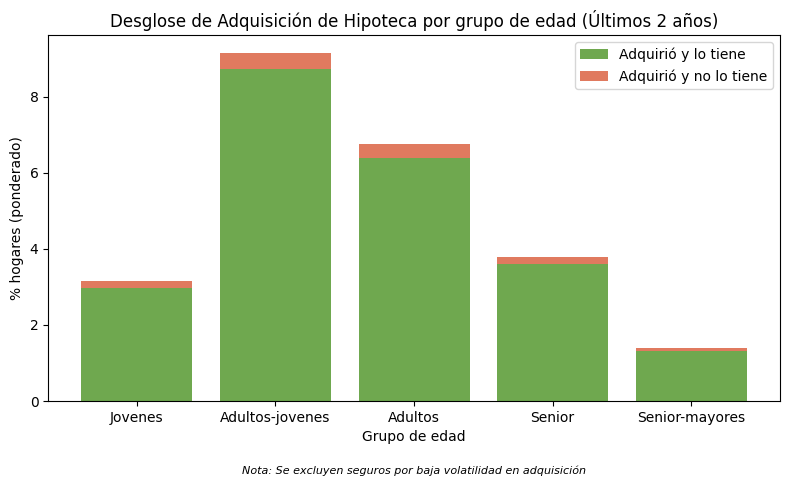

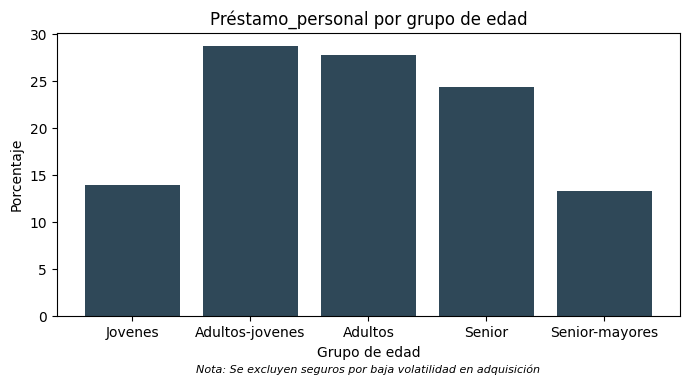

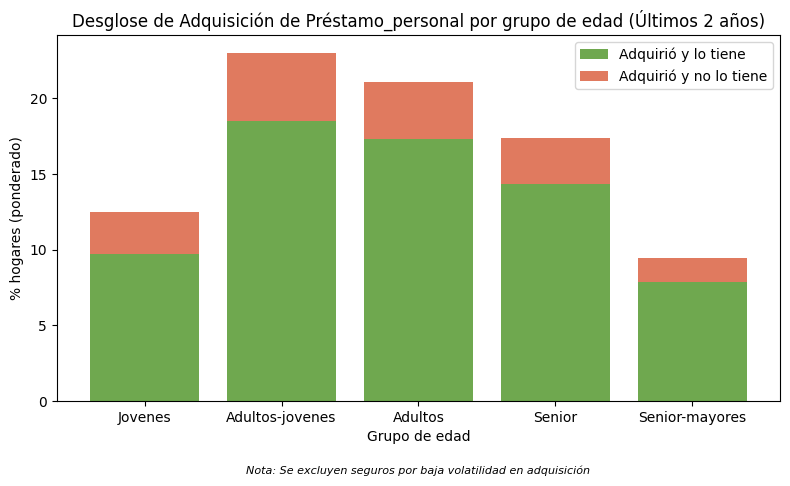

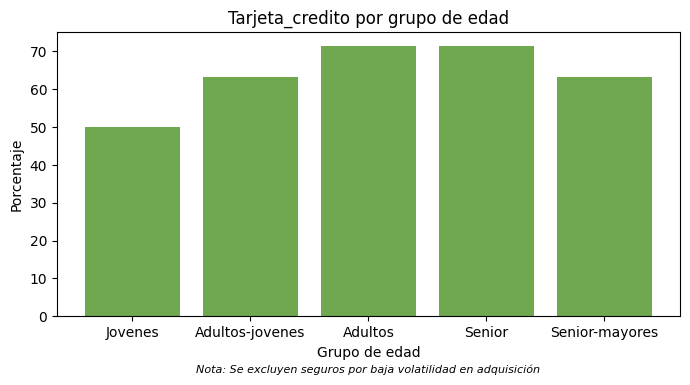

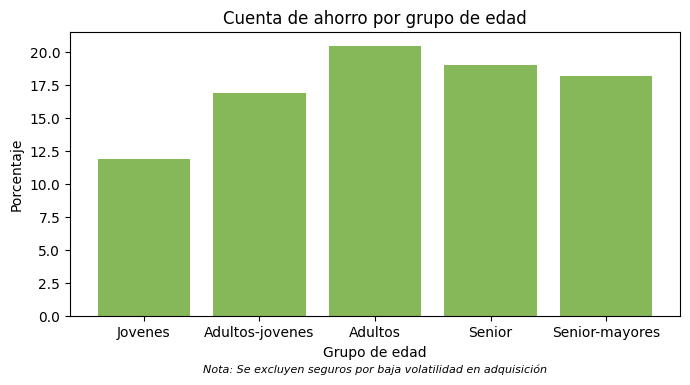

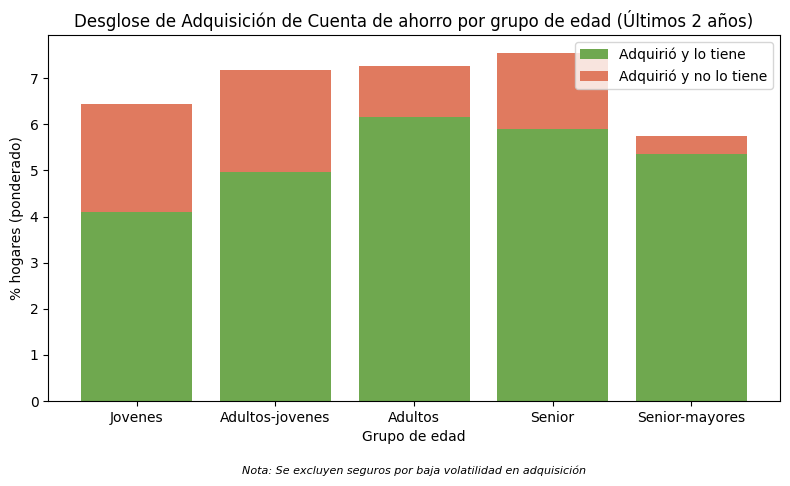

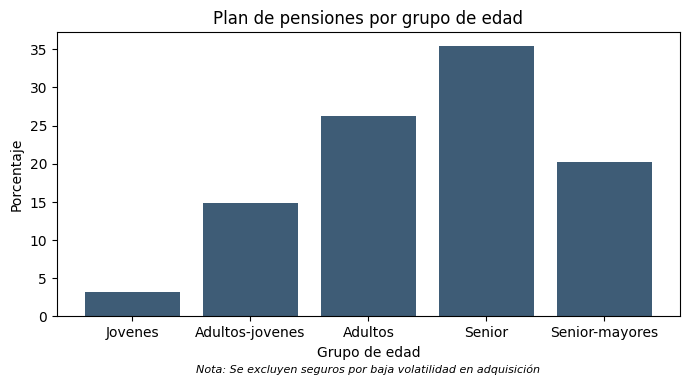

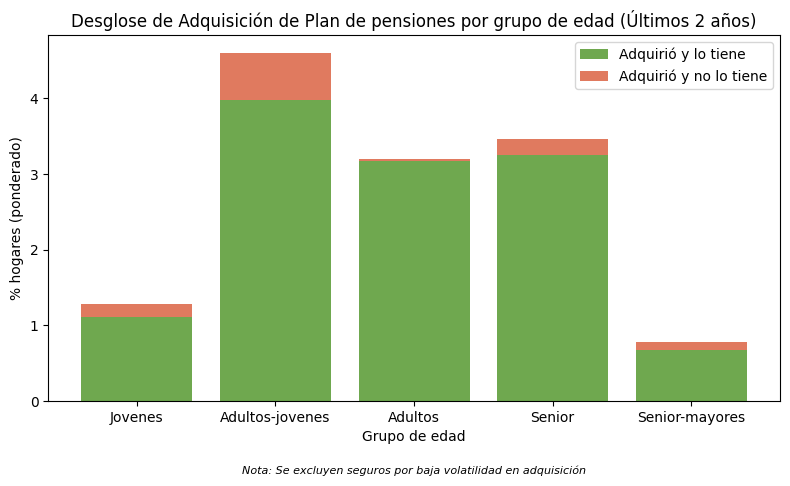

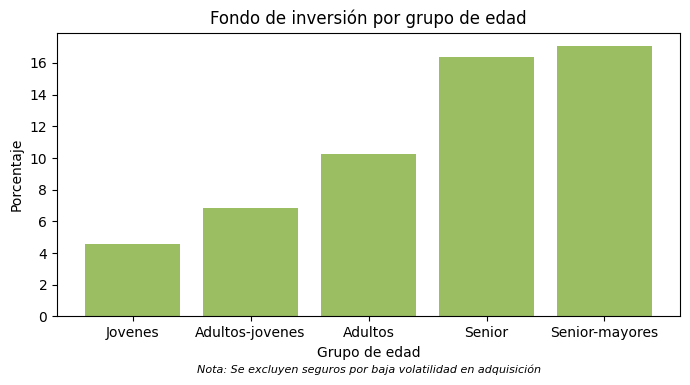

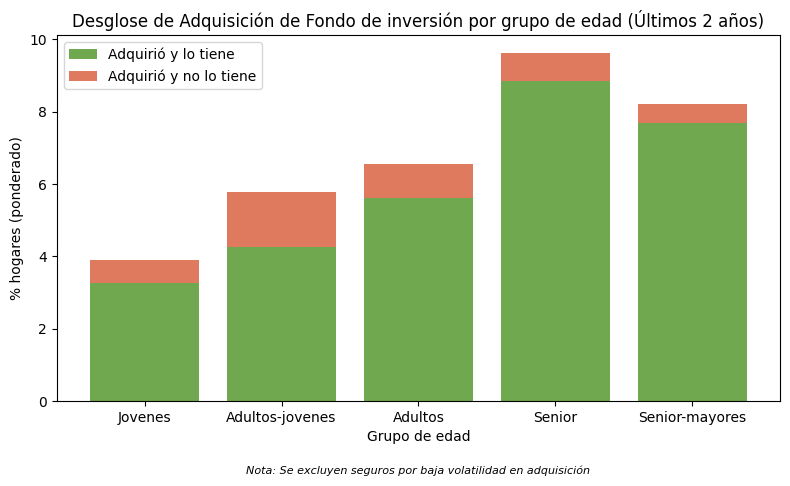

In [389]:
productos_clave = {
    'b0301': 'Hipoteca',
    'b0306': 'Préstamo_personal',
    'Tarjeta_credito': 'Tarjeta_credito',
    'b0308': 'Cuenta de ahorro',
    'b0302': 'Plan de pensiones',
    'b0303': 'Fondo de inversión',
}

edad_productos = tabla_por_grupo(eda_limpio, productos_clave, 'grupo_edad')
display(edad_productos.head(20))

for indicador in edad_productos['indicador'].dropna().unique():
    temp = edad_productos[edad_productos['indicador'] == indicador].dropna()

    color = {
        'Hipoteca': '#1E2F43',
        'Préstamo_personal': '#2F4858',
        'Tarjeta_credito': '#6FA84F',
        'Cuenta de ahorro': '#86B85A',
        'Plan de pensiones': '#3E5C76',
        'Fondo de inversión': '#9BBE63',

    }.get(indicador, '#1E2F43')

    plt.figure(figsize=(7, 4))
    plt.bar(temp['grupo_edad'].astype(str), temp['porcentaje'], color=color)
    plt.title(f'{indicador} por grupo de edad')
    plt.xlabel('Grupo de edad')
    plt.ylabel('Porcentaje')
    plt.annotate('Nota: Se excluyen seguros por baja volatilidad en adquisición',
                 xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=8, fontstyle='italic')
    plt.tight_layout()
    plt.show()

    # Añadimos el gráfico de "Adquisición Total" desglosado por estados para productos clave
    if indicador in ['Hipoteca', 'Préstamo_personal', 'Tarjeta_credito', 'Cuenta de ahorro', 'Plan de pensiones', 'Fondo de inversión', 'Criptomonedas', 'Acciones']:
        # Identificamos las variables b03 y b04 correspondientes
        b03_var = [k for k, v in productos_clave.items() if v == indicador][0]
        sufijo = b03_var.replace('b03', '')
        b04_var = f'b04{sufijo}'

        if b04_var in eda_limpio.columns:
            datos_acq = []
            for cat, sub in eda_limpio.groupby('grupo_edad', observed=False):
                if cat == 'Jovenes' and eda_limpio[eda_limpio['grupo_edad'] == 'Jovenes']['age'].max() < 18:
                    continue
                sub_val = sub[[b03_var, b04_var, 'weight']].dropna()
                denom = sub_val['weight'].sum()
                if denom > 0:
                    cond_si_si = (sub_val[b04_var] == 1) & (sub_val[b03_var] == 1)
                    cond_si_no = (sub_val[b04_var] == 1) & (sub_val[b03_var] == 0)

                    pct_si_si = (sub_val.loc[cond_si_si, 'weight'].sum() / denom) * 100
                    pct_si_no = (sub_val.loc[cond_si_no, 'weight'].sum() / denom) * 100
                else:
                    pct_si_si = pct_si_no = 0

                datos_acq.append({
                    'grupo_edad': str(cat),
                    'Adquirió y lo tiene': pct_si_si,
                    'Adquirió y no lo tiene': pct_si_no
                })

            df_plot = pd.DataFrame(datos_acq)

            plt.figure(figsize=(8, 5))
            plt.bar(df_plot['grupo_edad'], df_plot['Adquirió y lo tiene'], color='#6FA84F', label='Adquirió y lo tiene')
            plt.bar(df_plot['grupo_edad'], df_plot['Adquirió y no lo tiene'], bottom=df_plot['Adquirió y lo tiene'], color='#E07A5F', label='Adquirió y no lo tiene')

            plt.title(f'Desglose de Adquisición de {indicador} por grupo de edad (Últimos 2 años)')
            plt.xlabel('Grupo de edad')
            plt.ylabel('% hogares (ponderado)')
            plt.legend()
            plt.annotate('Nota: Se excluyen seguros por baja volatilidad en adquisición',
                         xy=(0.5, -0.2), xycoords='axes fraction', ha='center', fontsize=8, fontstyle='italic')
            plt.tight_layout()
            plt.show()


**Lectura de negocio:** la edad permite detectar etapas vitales. Las hipotecas y préstamos suelen asociarse a edades adultas, mientras que ahorro e inversión pueden requerir propuestas diferentes según el momento vital.

## 12. Ahorro, crédito y presión económica

Estos indicadores ayudan a identificar necesidades de productos de ahorro, financiación responsable y salud financiera.

,variable,indicador,porcentaje
0,b1000j,Capacidad de ahorro,29.933046
1,j0200,Estrés financiero,25.432683


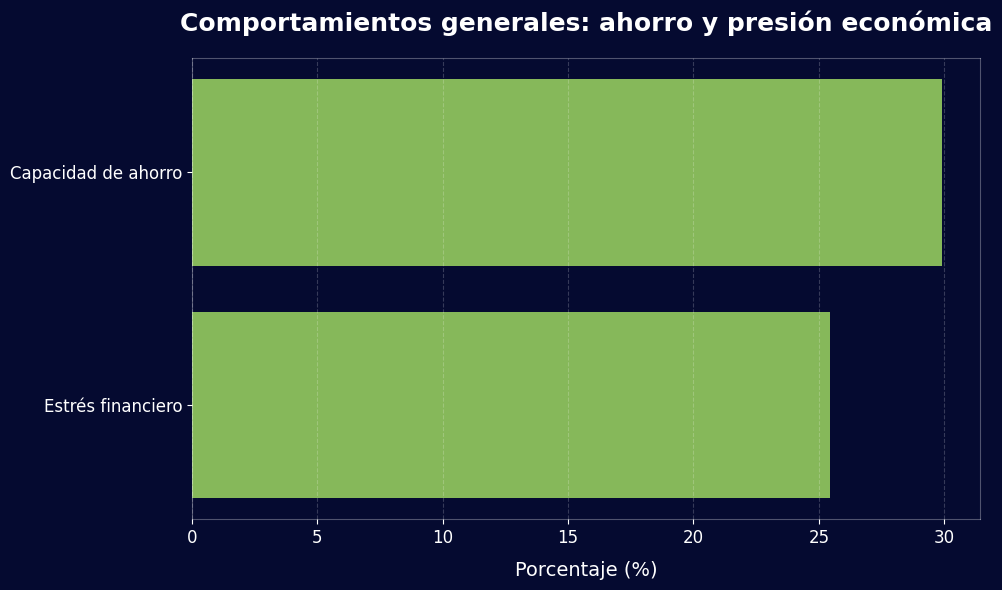

In [390]:
general = tabla_porcentajes(eda_limpio, comportamientos_generales)
display(general)

grafico_barras(
    general,
    titulo='Comportamientos generales: ahorro y presión económica',
    color='#86B85A'  # verde claro corporativo
)


## 13. Ahorro y presión económica por edad

,grupo_edad,indicador,porcentaje
0,Jovenes,Capacidad de ahorro,11.727878
1,Adultos-jovenes,Capacidad de ahorro,18.147350
2,Adultos,Capacidad de ahorro,26.495337
3,Senior,Capacidad de ahorro,36.793180
4,Senior-mayores,Capacidad de ahorro,47.875859
5,Jovenes,Estrés financiero,23.130796
6,Adultos-jovenes,Estrés financiero,25.215231
7,Adultos,Estrés financiero,27.640954
8,Senior,Estrés financiero,28.318286
9,Senior-mayores,Estrés financiero,22.968088


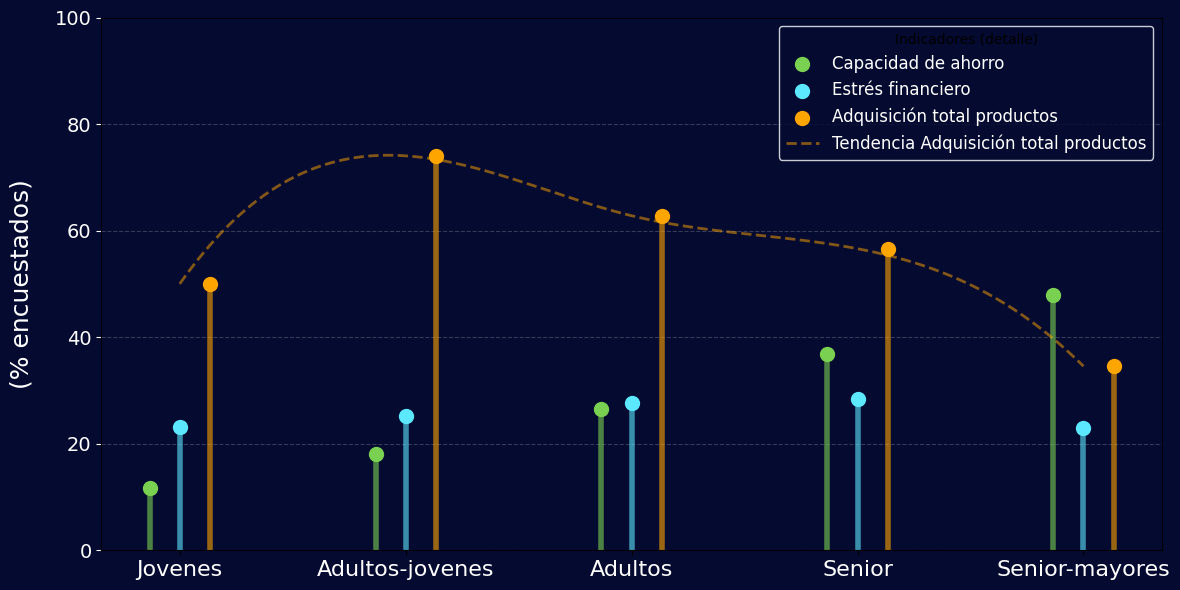

In [391]:
general_edad = tabla_por_grupo(eda_limpio, comportamientos_generales, 'grupo_edad')
display(general_edad)

# Pivotamos para tener los indicadores como columnas
df_plot = general_edad.pivot(index='grupo_edad', columns='indicador', values='porcentaje')

# Aseguramos el orden de edad creciente
orden_edad = ['Jovenes', 'Adultos-jovenes', 'Adultos', 'Senior', 'Senior-mayores']
df_plot = df_plot.reindex(orden_edad)

# Calculamos adquisición total por edad para la línea adicional
adq_edad = tabla_por_grupo(eda_limpio, productos_heatmap_adquisicion, 'grupo_edad')
adq_total = adq_edad.groupby('grupo_edad')['porcentaje'].sum().reindex(df_plot.index)

# Gráfico de Lollipop
plt.figure(figsize=(12, 6), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

# Unimos los indicadores con la adquisición total para tratarlos igual en el lollipop
df_completo = df_plot.copy()
df_completo['Adquisición total productos'] = adq_total

# Definimos colores específicos para cada variable
# Se usan los tonos viridis solicitados (#22a884, #7ad151) y naranja para adquisición
colores_dict = {
    'Capacidad de ahorro': '#7ad151',        # Verde Viridis
    'Estrés financiero': '#5CE8FF',          # Azul cielo solicitado
    'Adquisición total productos': '#FFA500' # Naranja
}

# Parámetros para agrupar los lollipops
n_indicadores = len(df_completo.columns)
n_grupos = len(df_completo.index)
espaciado_grupos = 2.0  # Aumentamos el espacio entre los centros de cada grupo (antes era 1.0 implícito)
width = 0.8 / n_indicadores
posiciones = np.arange(n_grupos) * espaciado_grupos

# Dibujamos lollipops para cada indicador
for i, col in enumerate(df_completo.columns):
    offset = (i - (n_indicadores - 1) / 2) * width
    x_pos = posiciones + offset
    color = colores_dict[col]

    # Líneas de los lollipops
    plt.vlines(x=x_pos, ymin=0, ymax=df_completo[col], color=color, alpha=0.6, linewidth=4)
    # Puntos de los lollipops
    plt.scatter(x_pos, df_completo[col], color=color, s=100, label=col, zorder=3)

    # Líneas de tendencia suavizadas (Spline) para cada parámetro
    # Solo dibujamos la tendencia para "Adquisición total productos" (excluimos Ahorro y Estrés por petición)
    if col not in ['Capacidad de ahorro', 'Estrés financiero']:
        # Generamos más puntos para una curva suave y con mayor curvatura
        x_new = np.linspace(posiciones.min(), posiciones.max(), 300)
        spline = make_interp_spline(posiciones, df_completo[col], k=3) # k=3 para mayor curvatura (cúbica)
        y_smooth = spline(x_new)

        plt.plot(x_new, y_smooth, color=color, linestyle='--', linewidth=2, alpha=0.5, label=f'Tendencia {col}')

#plt.title('Ahorro, presión y adquisición por grupo de edad (Lollipop Chart)', color='white', fontsize=22, pad=25)
#plt.xlabel('Grupo de edad', color='white', fontsize=18, labelpad=15)
plt.ylabel('(% encuestados)', color='white', fontsize=18, labelpad=15)
plt.xticks(posiciones, df_completo.index, rotation=0, color='white', fontsize=16)
ax.tick_params(axis='y', colors='white', labelsize=14)

# Primera leyenda (Arriba a la izquierda, fuera del gráfico por el bbox)
leg1 = plt.legend(title='Indicadores', bbox_to_anchor=(1.05, 1), loc='upper left',
           facecolor='#050a30', edgecolor='white', labelcolor='white')
ax.add_artist(leg1)

# Segunda leyenda (A la derecha, dentro del gráfico)
plt.legend(title='Indicadores (detalle)', loc='upper right',
           facecolor='#050a30', edgecolor='white', labelcolor='white', framealpha=0.8, fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.2, color='white')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


**Lectura de negocio:** si un grupo combina baja capacidad de ahorro y mayor presión económica, no conviene ofrecerle productos complejos o deuda agresiva. En esos casos tienen más sentido herramientas de control de gasto, microahorro y crédito responsable.

### 13.1 Análisis Avanzado de Marketing: Gap de Inversión (Liquidez vs Rentabilidad)

Este análisis identifica a los hogares que tienen capacidad de ahorro activa (b1000j) pero NO poseen productos de inversión (Fondos o Acciones). Estos representan el **target primario** para convertir ahorradores en inversores, transformando liquidez en rentabilidad por comisiones.


Porcentaje de ahorradores sin productos de inversión: 89.2%


C:\Users\raari\AppData\Local\Temp\ipykernel_27040\3211033144.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eda_limpio['tiene_inversion'] = ((eda_limpio['b0303'] == 1) | (eda_limpio['b0304'] == 1)).astype(int)


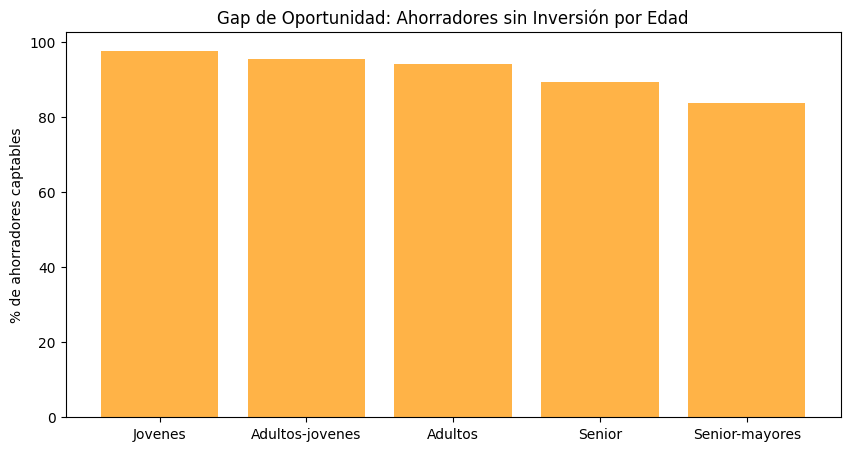

In [392]:
# Definimos inversión como Fondos o Acciones
eda_limpio['tiene_inversion'] = ((eda_limpio['b0303'] == 1) | (eda_limpio['b0304'] == 1)).astype(int)

# Segmentamos: Ahorradores sin inversión
target_marketing = eda_limpio[(eda_limpio['b1000j'] == 1) & (eda_limpio['tiene_inversion'] == 0)]
pct_target = (target_marketing['weight'].sum() / eda_limpio[eda_limpio['b1000j'] == 1]['weight'].sum()) * 100

print(f"Porcentaje de ahorradores sin productos de inversión: {pct_target:.1f}%")

# Ver distribución por edad de este target
gap_edad = tabla_por_grupo(eda_limpio[eda_limpio['b1000j'] == 1], {'tiene_inversion': 'Inversores Actuales'}, 'grupo_edad')
gap_edad['Gap_Oportunidad'] = 100 - gap_edad['porcentaje']

plt.figure(figsize=(10, 5))
plt.bar(gap_edad['grupo_edad'], gap_edad['Gap_Oportunidad'], color='#FFB347')
plt.title('Gap de Oportunidad: Ahorradores sin Inversión por Edad')
plt.ylabel('% de ahorradores captables')
plt.show()


**Conclusión de Marketing:** Los ahorradores con alta liquidez pero sin inversión son el segmento donde el banco pierde ingresos potenciales. La estrategia debe ser mover saldos de cuentas de ahorro (liquidez) hacia fondos (rentabilidad).


### 13.2 Análisis Avanzado de Riesgos: Alerta de Mora (Estrés Financiero)

Cruzamos el estrés financiero (Gastos > Ingresos, j0200) con la tenencia de préstamos y microcréditos. Un hogar con estrés y deuda es una **Alerta Roja** para el departamento de Riesgos.


C:\Users\raari\AppData\Local\Temp\ipykernel_27040\3691693035.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eda_limpio['tiene_deuda_consumo'] = ((eda_limpio['b0306'] == 1) | (eda_limpio['b0310'] == 1)).astype(int)


Porcentaje de deudores en situación de estrés financiero: 28.2%


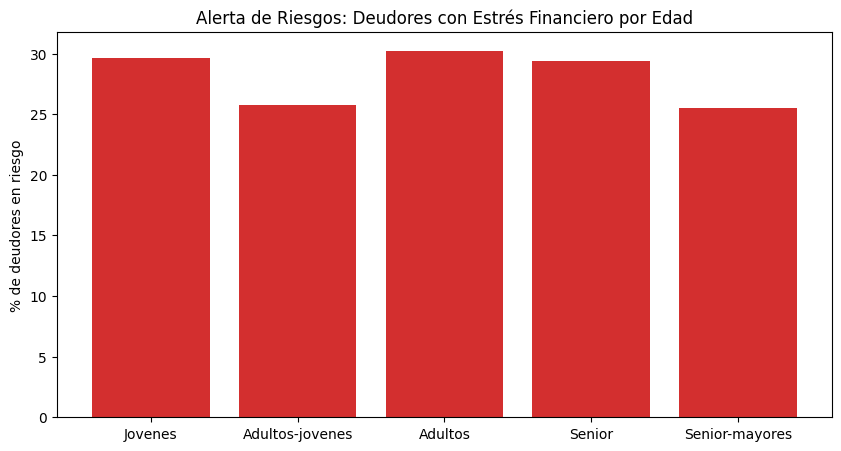

In [393]:
# Definimos deuda de consumo/microcrédito
eda_limpio['tiene_deuda_consumo'] = ((eda_limpio['b0306'] == 1) | (eda_limpio['b0310'] == 1)).astype(int)

# Segmentamos: Deudores con estrés financiero
alerta_riesgo = eda_limpio[(eda_limpio['j0200'] == 1) & (eda_limpio['tiene_deuda_consumo'] == 1)]
pct_mora_potencial = (alerta_riesgo['weight'].sum() / eda_limpio[eda_limpio['tiene_deuda_consumo'] == 1]['weight'].sum()) * 100

print(f"Porcentaje de deudores en situación de estrés financiero: {pct_mora_potencial:.1f}%")

# Distribución por edad del riesgo
riesgo_edad = tabla_por_grupo(eda_limpio[eda_limpio['tiene_deuda_consumo'] == 1], {'j0200': 'Deudores en Estrés'}, 'grupo_edad')

plt.figure(figsize=(10, 5))
plt.bar(riesgo_edad['grupo_edad'], riesgo_edad['porcentaje'], color='#D32F2F')
plt.title('Alerta de Riesgos: Deudores con Estrés Financiero por Edad')
plt.ylabel('% de deudores en riesgo')
plt.show()


**Conclusión de Riesgos:** Los segmentos con alta concentración de microcréditos y estrés financiero (especialmente jóvenes) requieren políticas de admisión más estrictas o planes de refinanciación preventiva para evitar el default.


## 14. Validación estadística de diferencias entre grupos (con pesos y V de Cramer)

Para responder a la recomendación de validar las diferencias encontradas con rigor metodológico, se aplica el **test Chi-cuadrado de independencia** considerando el **diseño muestral (pesos)** y calculando la **V de Cramer** para medir el tamaño del efecto.

**Ajustes realizados:**
1.  **Uso de pesos:** El test Chi-cuadrado estándar se basa en conteos. Para microdatos de encuestas, usamos la tabla de contingencia ponderada (suma de pesos) para que el test sea representativo de la población.
2.  **V de Cramer:** Indica la fuerza de la asociación.
    *   < 0.1: Asociación despreciable.
    *   0.1 - 0.3: Asociación baja.
    *   0.3 - 0.5: Asociación moderada.
    *   > 0.5: Asociación alta.

**Hipótesis del test:**

- H0: no existe relación estadísticamente significativa entre las variables.
- H1: sí existe relación estadísticamente significativa entre las variables.

Se toma como referencia un nivel de significación del 5% (p-value < 0,05).


In [394]:
from scipy.stats import chi2_contingency

def calcular_v_cramer(chi2, n, filas, columnas):
    """Calcula la V de Cramer para cuantificar el tamaño del efecto."""
    min_dim = min(filas - 1, columnas - 1)
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

def test_chi_cuadrado_microdatos(df, variable_grupo, variable_respuesta, peso_col='weight', nombre_respuesta=None):
    """Aplica Chi-cuadrado ponderado entre una variable de grupo y una respuesta binaria."""
    nombre_respuesta = nombre_respuesta or variable_respuesta

    # Limpieza de nulos y asegurar valores 0/1
    columnas = [variable_grupo, variable_respuesta]
    if peso_col in df.columns:
        columnas.append(peso_col)

    temp = df[columnas].dropna().copy()
    temp = temp[temp[variable_respuesta].isin([0, 1])]

    if temp.empty:
        return None

    # Tabla de contingencia PONDERADA (usando la suma de los pesos)
    if peso_col in temp.columns:
        # Ponderamos la tabla de contingencia
        tabla = temp.groupby([variable_grupo, variable_respuesta], observed=False)[peso_col].sum().unstack(fill_value=0)
        n_total = temp[peso_col].sum()
    else:
        tabla = pd.crosstab(temp[variable_grupo], temp[variable_respuesta])
        n_total = len(temp)

    # El test necesita al menos dos filas y dos columnas
    if tabla.shape[0] < 2 or tabla.shape[1] < 2:
        print(f'No se puede aplicar el test para {nombre_respuesta}: tabla insuficiente.')
        return None

    # Manejo de ceros para evitar errores en chi2_contingency (ValueError: expected frequencies has a zero element)
    # Si hay alguna celda con 0 absoluto, sumamos una cantidad ínfima (corrección de continuidad/suavizado)
    if (tabla == 0).any().any():
        tabla = tabla + 1e-9

    # Ejecución del test sobre la tabla ponderada
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # Cálculo de la V de Cramer
    v_cramer = calcular_v_cramer(chi2, n_total, tabla.shape[0], tabla.shape[1])

    resultado = {
        'variable_grupo': variable_grupo,
        'variable_respuesta': variable_respuesta,
        'indicador': nombre_respuesta,
        'chi2': chi2,
        'p_value': p_value,
        'v_cramer': round(v_cramer, 4),
        'significativo_5%': 'Sí' if p_value < 0.05 else 'No',
        'fuerza_asociacion': 'Baja' if v_cramer < 0.3 else ('Moderada' if v_cramer < 0.5 else 'Alta')
    }

    print(f'Indicador: {nombre_respuesta}')
    print(f'Chi2: {chi2:.4f} | p-value: {p_value:.6f}')
    print(f'V de Cramer: {v_cramer:.4f} ({resultado["fuerza_asociacion"]})')
    print('Conclusión:', 'Diferencia significativa' if p_value < 0.05 else 'No significativa')
    display(tabla.round(1))

    return resultado


# Tests principales: diferencias por grupo de edad (PONDERADOS sobre Productos Core)
tests_a_realizar = {
    'b0301': 'Tenencia de hipoteca',
    'b0306': 'Tenencia de préstamo personal',
    'Tarjeta_credito': 'Tenencia de Tarjeta_credito',
    'b0308': 'Tenencia de cuenta de ahorro',
    'b0302': 'Tenencia de plan de pensiones',
    'b0303': 'Tenencia de fondo de inversión',
    'b1000j': 'Capacidad de ahorro (últimos 12 meses)',
    'j0200': 'Gastos superiores a ingresos',
    'j0900a': 'Préstamo rechazado',
    'j0900b': 'Cuantía concedida inferior',
    'j0900c': 'No solicitado por miedo al rechazo'
}

resultados_tests = []

for variable, nombre in tests_a_realizar.items():
    if variable in eda_limpio.columns:
        res = test_chi_cuadrado_microdatos(eda_limpio, 'grupo_edad', variable, nombre_respuesta=nombre)
        if res is not None:
            resultados_tests.append(res)
        print('-' * 80)

resultados_tests = pd.DataFrame(resultados_tests)
display(resultados_tests.sort_values('p_value'))


Indicador: Tenencia de hipoteca
Chi2: 4675996.4137 | p-value: 0.000000
V de Cramer: 0.3605 (Moderada)
Conclusión: Diferencia significativa


b0301,0.0,1.0
grupo_edad,,
Jovenes,6038947.5,355793.1
Adultos-jovenes,3625209.5,2020706.9
Adultos,3731228.5,4045504.0
Senior,4507614.5,2632902.9
Senior-mayores,7517102.9,1507285.9


--------------------------------------------------------------------------------
Indicador: Tenencia de préstamo personal
Chi2: 973605.7625 | p-value: 0.000000
V de Cramer: 0.1645 (Baja)
Conclusión: Diferencia significativa


b0306,0.0,1.0
grupo_edad,,
Jovenes,5501898.7,892841.9
Adultos-jovenes,4027877.6,1620815.6
Adultos,5625001.8,2166812.3
Senior,5388174.6,1737751.0
Senior-mayores,7829505.0,1203646.2


--------------------------------------------------------------------------------
Indicador: Tenencia de Tarjeta_credito
Chi2: 893932.4596 | p-value: 0.000000
V de Cramer: 0.1594 (Baja)
Conclusión: Diferencia significativa


...

j0900b,0.0,1.0
grupo_edad,,
Jovenes,6171531.2,156902.3
Adultos-jovenes,5560968.1,82773.8
Adultos,7546760.9,250187.7
Senior,7030443.9,111459.2
Senior-mayores,8909952.8,53073.4


--------------------------------------------------------------------------------
Indicador: No solicitado por miedo al rechazo
Chi2: 119933.3652 | p-value: 0.000000
V de Cramer: 0.0578 (Baja)
Conclusión: Diferencia significativa


j0900c,0.0,1.0
grupo_edad,,
Jovenes,6177034.4,151399.1
Adultos-jovenes,5404857.0,238884.8
Adultos,7488707.6,308241.0
Senior,6948779.3,193123.8
Senior-mayores,8812126.1,150900.1


--------------------------------------------------------------------------------


,variable_grupo,variable_respuesta,indicador,chi2,p_value,v_cramer,significativo_5%,fuerza_asociacion
0,grupo_edad,b0301,Tenencia de hipoteca,4.675996e+06,0.0,0.3605,Sí,Moderada
1,grupo_edad,b0306,Tenencia de préstamo personal,9.736058e+05,0.0,0.1645,Sí,Baja
2,grupo_edad,Tarjeta_credito,Tenencia de Tarjeta_credito,8.939325e+05,0.0,0.1594,Sí,Baja
3,grupo_edad,b0308,Tenencia de cuenta de ahorro,2.006325e+05,0.0,0.0747,Sí,Baja
4,grupo_edad,b0302,Tenencia de plan de pensiones,2.411445e+06,0.0,0.2589,Sí,Baja
5,grupo_edad,b0303,Tenencia de fondo de inversión,8.607783e+05,0.0,0.1548,Sí,Baja
6,grupo_edad,b1000j,Capacidad de ahorro (últimos 12 meses),2.965323e+06,0.0,0.2873,Sí,Baja
7,grupo_edad,j0200,Gastos superiores a ingresos,9.788473e+04,0.0,0.0523,Sí,Baja
8,grupo_edad,j0900a,Préstamo rechazado,1.137455e+05,0.0,0.0563,Sí,Baja
9,grupo_edad,j0900b,Cuantía concedida inferior,1.814021e+05,0.0,0.0711,Sí,Baja


## 15. Ranking de segmentos por salud financiera y actividad comercial

En esta sección final antes de las conclusiones, generamos un **Ranking de Segmentos de Edad** basado en tres dimensiones críticas para el negocio:
1.  **Resiliencia (Estrés Financiero):** Penaliza el ranking si el segmento tiene altos niveles de gastos superiores a ingresos.
2.  **Oportunidad (Capacidad de Ahorro):** Premia el ranking si el segmento tiene excedentes para invertir.
3.  **Dinamismo (Adquisición Reciente):** Mide qué tan activo está el segmento en la contratación de nuevos productos.


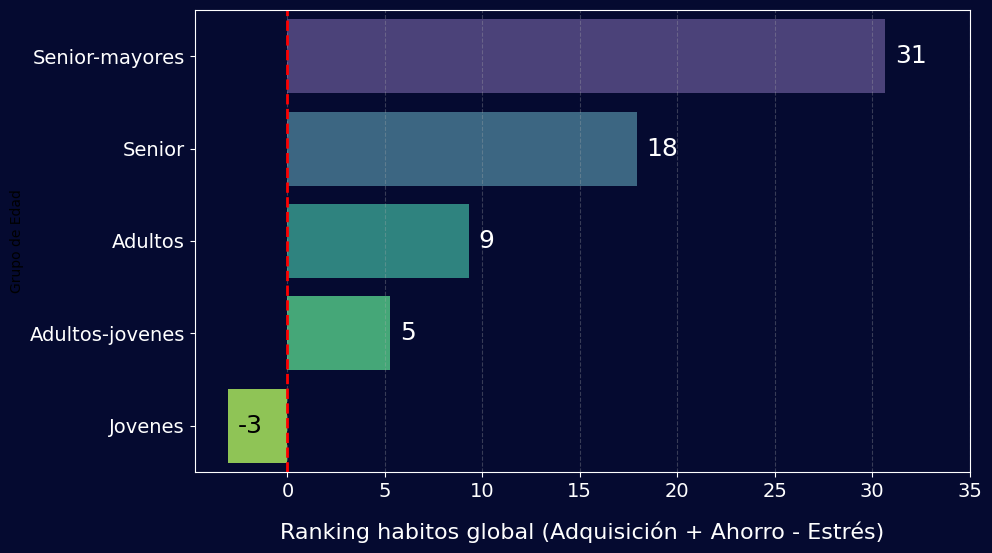

,Grupo de Edad,Capacidad Ahorro (%),Estrés Financiero (%),Media Adquisición (%),Score de Oportunidad
0,Senior-mayores,47.875859,22.968088,5.757262,30.67
1,Senior,36.793180,28.318286,9.433768,17.91
2,Adultos,26.495337,27.640954,10.464997,9.32
3,Adultos-jovenes,18.147350,25.215231,12.339501,5.27
4,Jovenes,11.727878,23.130796,8.335301,-3.07


In [395]:
# 1. Calculamos los tres pilares por grupo de edad
# Pilar Ahorro (Premio)
ranking_ahorro = tabla_por_grupo(eda_limpio, {'b1000j': 'Ahorro'}, 'grupo_edad')
# Pilar Estrés (Penalización)
ranking_estres = tabla_por_grupo(eda_limpio, {'j0200': 'Estres'}, 'grupo_edad')
# Pilar Adquisición (Media de adquisición de todos los productos clave)
adq_general = tabla_por_grupo(eda_limpio, productos_heatmap_adquisicion, 'grupo_edad')
ranking_adq = adq_general.groupby('grupo_edad')['porcentaje'].mean().reset_index()

# 2. Unificamos en un DataFrame de Ranking
ranking_final = pd.merge(ranking_ahorro[['grupo_edad', 'porcentaje']], 
                         ranking_estres[['grupo_edad', 'porcentaje']], 
                         on='grupo_edad', suffixes=('_ahorro', '_estres'))
ranking_final = pd.merge(ranking_final, ranking_adq, on='grupo_edad')
ranking_final.columns = ['Grupo de Edad', 'Capacidad Ahorro (%)', 'Estrés Financiero (%)', 'Media Adquisición (%)']

# 3. Calculamos el Score de Oportunidad de Negocio
# Fórmula: (Ahorro + Adquisición) - Estrés
# Normalizamos para que sea un índice comparable
ranking_final['Score de Oportunidad'] = (ranking_final['Capacidad Ahorro (%)'] + 
                                         ranking_final['Media Adquisición (%)'] - 
                                         ranking_final['Estrés Financiero (%)']).round(2)

# Ordenamos el ranking
ranking_final = ranking_final.sort_values('Score de Oportunidad', ascending=False).reset_index(drop=True)

# Visualización del Ranking
plt.figure(figsize=(10, 6), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

# Usamos viridis mapeado al score para el color de las barras
norm = plt.Normalize(ranking_final['Score de Oportunidad'].min(), ranking_final['Score de Oportunidad'].max())
colors = plt.cm.viridis(norm(ranking_final['Score de Oportunidad']))

sns.barplot(data=ranking_final, x='Score de Oportunidad', y='Grupo de Edad', palette='viridis', hue='Grupo de Edad', legend=False)
#plt.title('Ranking de Segmentos: Oportunidad de Negocio Integral', color='white', fontsize=20, pad=20)
plt.xlabel('Ranking habitos global (Adquisición + Ahorro - Estrés)', color='white', fontsize=16, labelpad=15)
#plt.ylabel('Edad', color='white', fontsize=16, labelpad=15)

# Ajustamos colores de los ejes
ax.tick_params(colors='white', labelsize=14)
for spine in ax.spines.values():
    spine.set_color('white')

# Añadimos etiquetas de valor
for i, v in enumerate(ranking_final['Score de Oportunidad']):
    color_label = 'black' if v == -3.07 else 'white'
    # Redondeamos a cero decimales y aumentamos tamaño de fuente
    plt.text(v + 0.5, i, f'{int(round(v))}', color=color_label, va='center', fontweight='normal', fontsize=18)

# Ajustamos límites y añadimos línea en el cero
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlim(right=35)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

display(ranking_final)


**Interpretación del Ranking:**
*   **Segmentos con Score Alto:** Son la prioridad comercial. Tienen recursos (ahorro), están activos contratando (dinamismo) y su riesgo es controlado (bajo estrés).
*   **Segmentos con Score Bajo:** Requieren una estrategia de acompañamiento o saneamiento. El banco debe centrarse en reducir su estrés financiero o mejorar su educación financiera antes de intentar ventas agresivas.


# Conclusiones finales: comportamiento financiero y oportunidades de negocio

A partir del análisis de la ECF 2021, se extraen las siguientes conclusiones estratégicas para la entidad:

1. **Segmentación por ciclo de vida:** Las hipotecas y préstamos se concentran en los segmentos de 35-54 años, mientras que los fondos de inversión y planes de pensiones crecen en los segmentos de mayor edad y estabilidad financiera.
2. **Oportunidad en productos de inversión:** Existe un gap significativo entre la capacidad de ahorro reportada y la tenencia de productos de valor añadido (fondos de inversión, planes de pensiones).
3. **Resiliencia financiera:** El análisis de exclusión y miedo al rechazo de crédito permite identificar nichos donde mejorar la comunicación de riesgos y la transparencia en la concesión.

El análisis de los microdatos de la ECF 2021 permite identificar patrones relevantes sobre el comportamiento financiero de la población española. Se observa qué productos financieros están más extendidos, cuáles se adquieren con mayor frecuencia y qué oportunidades puede aprovechar el banco para adaptar su estrategia comercial.

## 1. Productos financieros consolidados

Los productos con mayor presencia son la cuenta de ahorro, la tarjeta de crédito y la hipoteca. Estos productos forman parte del comportamiento financiero habitual de la población. La validación estadística confirma que la tenencia de estos productos está fuertemente vinculada al grupo de edad (V de Cramer significativa), lo que permite una segmentación precisa.

**Interpretación de negocio:** estos productos ya están consolidados, representando una base para fidelización y venta cruzada. El alto score de oportunidad en los segmentos Senior y Adultos refuerza su papel como pilares de rentabilidad.

**Recomendación:** utilizar los productos consolidados como entrada para ofrecer paquetes personalizados:

- Tarjeta + ahorro automático para perfiles jóvenes.
- Hipoteca + cuenta nómina vinculada para adultos-jóvenes.
- Seguros de salud y vida para perfiles senior con alta capacidad de ahorro.

## 2. Productos con mayor adquisición reciente

La adquisición reciente se concentra principalmente en tarjeta de crédito, préstamo personal y cuenta de ahorro. Esto indica que existe una demanda activa en productos de financiación de consumo y liquidez inmediata.

**Interpretación de negocio:** estos productos deberían ser prioritarios para campañas comerciales de captación, ya que muestran el mayor dinamismo en los últimos 2 años.

**Recomendación:** reforzar la oferta de estos productos mediante:

- Procesos de contratación 100% digitales para reducir el "abandono" detectado en el análisis de estados.
- Campañas de "Next Best Action" basadas en el ranking de segmentos.
- Mejora de la comunicación para reducir el "miedo al rechazo" detectado en los tests de exclusión.

## 3. Financiación: hipotecas, préstamos y alerta de riesgo

Las hipotecas y préstamos personales muestran una concentración clara en edades adultas (35-54 años). Sin embargo, el análisis de **Alerta de Mora** revela que un porcentaje relevante de deudores (especialmente en el segmento joven) se encuentra en situación de estrés financiero (Gastos > Ingresos).

**Interpretación de negocio:** la financiación debe ser proactiva pero responsable. El estrés financiero es un indicador temprano de riesgo de default que el banco debe monitorizar.

**Recomendación:** crear ofertas diferenciadas y seguras:

- Planes de refinanciación preventiva para segmentos detectados en la "Alerta Roja" de Riesgos.
- Análisis de capacidad de pago más estricto para productos de microcrédito en perfiles con alto estrés.
- Herramientas de control de gasto integradas en la app para mejorar la salud financiera del cliente.

## 4. Ahorro e inversión: El "Gap" de Oportunidad

El análisis del **Gap de Inversión** muestra una sólida capacidad de ahorro en gran parte de la población, pero una baja conversión hacia productos de valor añadido como fondos de inversión. Muchos ahorradores mantienen su excedente en liquidez (cuentas de ahorro) perdiendo rentabilidad y generando menos comisiones para el banco.

**Interpretación de negocio:** existe una oportunidad masiva para convertir el ahorro pasivo en inversión gestionada, especialmente en los segmentos Senior y Adultos que lideran el Ranking de Oportunidad.

**Recomendación:** impulsar la migración de saldos mediante:

- Campañas de conversión: "De Ahorrador a Inversor" centradas en el gap detectado.
- Fondos de inversión con aportaciones periódicas bajas para democratizar el acceso.
- Educación financiera que explique la pérdida de poder adquisitivo por inflación en cuentas de ahorro.

## 5. Segmentación Estratégica y Ranking de Oportunidad

El **Ranking de Segmentos** sitúa a los grupos **Senior** y **Adultos** en la cima de la oportunidad de negocio integral (alto ahorro, dinamismo aceptable y estrés controlado). Por contra, los **Jóvenes** requieren una estrategia de acompañamiento debido a su mayor exposición al estrés financiero.

**Interpretación de negocio:** la inversión publicitaria y el esfuerzo comercial deben priorizar los segmentos con mayor Score de Oportunidad para maximizar el retorno.

**Recomendación por segmento:**

- **Senior y Adultos:** Foco en inversión, fondos de pensiones y protección patrimonial.
- **Adultos-Jóvenes:** Foco en consolidación de deuda (hipotecas) y seguros.
- **Jóvenes:** Foco en productos de entrada (cuentas, tarjetas), ahorro automático y herramientas de salud financiera para reducir su estrés.

## 6. Conclusión general

Es imperativo ajustar la estrategia de negocio del banco basándose en el comportamiento financiero real observado. No se trata de una oferta única, sino de una arquitectura de productos adaptada al ciclo de vida y a la salud financiera del cliente.

La entidad debe centrarse en:
1. **Captación** en productos dinámicos (Tarjetas y Préstamos).
2. **Conversión** de ahorradores en inversores (Fondos de Inversión).
3. **Prevención** de riesgos en segmentos con alto estrés financiero.

En conclusión, la integración de la validación estadística y el ranking de oportunidad proporciona una hoja de ruta clara para una gestión bancaria eficiente y centrada en el cliente.